# Projekt 2 – Preference Learning


Przygotowali: Maciej Szymaniak oraz Piotr Szymaczek

Celem projektu było przeprowadzenie eksperymentów z uczenia preferencji na zbiorze danych z mammografii i porównanie trzech podejść do modelowania.

Trenowane modele:
- Model 1 – XGBoost
- Model 2 – ANN-UTADIS
- Model 3 – Sień neuronowa

In [246]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import xgboost as xgb
from xgboost import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

from typing import Tuple
import shap


## 1. Opis zbioru danych

Zbiór Mammographic Mass zawiera wyniki badań mammograficznych 830 pacjentek. Celem jest klasyfikacja zmiany jako łagodnej (0) lub złośliwej (1).

Kolumny (kolejność zgodna z dokumentacją UCI):
- `birads` – ocena BI-RADS, skala 1–5, wyżej = większe podejrzenie złośliwości
- `age` – wiek pacjentki
- `shape` – kształt masy: okrągły=1, owalny=2, płatowaty=3, nieregularny=4
- `margin` – margines: ostry=1 do łagodny=5
- `density` – gęstość masy (4 poziomy)

Wszystkie wartości są znormalizowane do [0, 1]. Traktuję kryteria jako kryteria zysku – wyższa wartość oznacza większe prawdopodobieństwo złośliwości. Gęstość może nie być do końca monotoniczna, ale przyjmuję to uproszczenie.

In [247]:
df = pd.read_csv('mammographic.csv', header=None)
df.columns = ['birads', 'age', 'shape', 'margin', 'density', 'class']

criteria         = ['birads', 'age', 'shape', 'margin', 'density']
criterion_labels = ['BI-RADS', 'Wiek', 'Kształt', 'Margines', 'Gęstość']

print(f'Wymiary zbioru: {df.shape}')
print(f'\nRozkład klas:')
print(df['class'].value_counts().rename({0: 'Łagodna (0)', 1: 'Złośliwa (1)'}), '\n')
display(df.describe().round(4))


Wymiary zbioru: (830, 6)

Rozkład klas:
class
Łagodna (0)     427
Złośliwa (1)    403
Name: count, dtype: int64 



,birads,age,shape,margin,density,class
count,830.0000,830.0000,830.0000,830.0000,830.0000,830.0000
mean,0.0799,0.4844,0.5940,0.4533,0.6386,0.4855
std,0.0343,0.1881,0.4141,0.3918,0.1170,0.5001
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0727,0.3590,0.3333,0.0000,0.6667,0.0000
50%,0.0727,0.5000,0.6667,0.5000,0.6667,0.0000
75%,0.0909,0.6154,1.0000,0.7500,0.6667,1.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Zbiór jest dość zbalansowany – ok. 54% przypadków łagodnych, 46% złośliwych. Nie ma tu poważnego problemu z nierównowagą klas, więc standardowe miary (Accuracy, F1, AUC) powinny sensownie działać bez dodatkowego ważenia próbek.


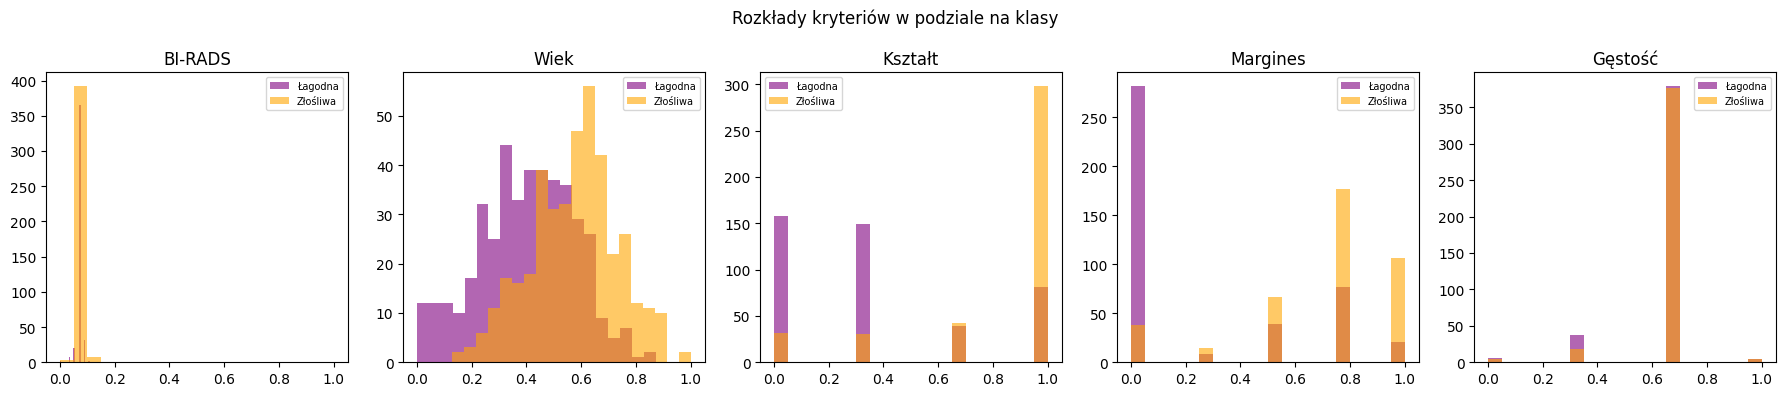

In [248]:
# Rozkłady kryteriów z podziałem na klasy
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, (col, lbl) in enumerate(zip(criteria, criterion_labels)):
    for cls, color, name in zip([0, 1], ['purple', 'orange'], ['Łagodna', 'Złośliwa']):
        axes[i].hist(df[df['class']==cls][col], bins=20, alpha=0.6, color=color, label=name)
    axes[i].set_title(lbl)
    axes[i].legend(fontsize=7)
plt.suptitle('Rozkłady kryteriów w podziale na klasy')
plt.tight_layout()
plt.show()


Z histogramów widać, że BI-RADS dość wyraźnie rozdziela klasy. Kształt i margines też mają widoczne różnice między klasami.

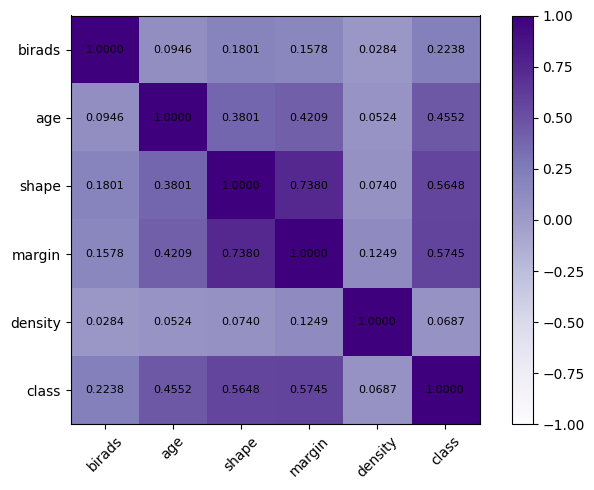

In [249]:
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df.corr()
# -1 : 1; algorytm sprawdza, czy gdy wartości w jednej kolumnie rosną,
#to wartości w drugiej kolumnie również rosną, maleją, czy może zachowują się zupełnie chaotycznie.
im = ax.imshow(corr_matrix, cmap='Purples', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(df.columns)))
ax.set_yticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=45)
ax.set_yticklabels(df.columns)
for i in range(len(df.columns)):
    for j in range(len(df.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.4f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

Korelacje z etykietą `class` są umiarkowane dla wszystkich kryteriów. Najsilniej koreluje `shape` i `margin`. Nie wystepują wartości ujemne.


## 2. Przygotowanie danych

In [250]:
X_all = df[criteria].values
y_all = df['class'].values.astype(float)

X_tr_shared, X_te_shared, y_tr_shared, y_te_shared = train_test_split(
    X_all, y_all, test_size=0.2, random_state=1234, stratify=y_all
)

def metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1':       round(f1_score(y_true, y_pred), 4),
        'AUC':      round(roc_auc_score(y_true, y_prob), 4),
    }

print(f'Zbiór treningowy: {X_tr_shared.shape[0]} próbek')
print(f'Zbiór testowy:    {X_te_shared.shape[0]} próbek')
print(f'Proporcja kl. 1 – train: {y_tr_shared.mean():.4f}, test: {y_te_shared.mean():.4f}')


Zbiór treningowy: 664 próbek
Zbiór testowy:    166 próbek
Proporcja kl. 1 – train: 0.4849, test: 0.4880


## 3. XGBoost


In [251]:
import pandas as pd
from xgboost import plot_tree
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

criteria_nr = 5

X_train = pd.DataFrame(X_tr_shared, columns=[str(i) for i in range(criteria_nr)])
X_test  = pd.DataFrame(X_te_shared, columns=[str(i) for i in range(criteria_nr)])
y_train = pd.Series(y_tr_shared.astype(int))
y_test  = pd.Series(y_te_shared.astype(int))

In [252]:
# Initialize the XGBoost parameters
params = {
    'max_depth': criteria_nr * 2,  # Maximum depth of a tree
    'eta': 0.1,  # Learning rate
    'nthread': 2,  # Number of parallel threads
    'seed': 0,  # Random seed
    'eval_metric': 'rmse',  # Evaluation metric
    'monotone_constraints': '('
    + ','.join(['1'] * criteria_nr)
    + ')',  # Monotonic constraints for each criterion (1 = increasing, -1 = decreasing, 0 = no constraint)
    'n_estimators': 1,  # Number of boosting rounds, or trees
}


In [253]:
# Create the XGBoost model
model = xgb.XGBClassifier(**params)

# Train the model
_ = model.fit(X_train, y_train)


In [254]:
# Predict on the training set
y_pred = model.predict(X_train)
predictions = [round(value) for value in y_pred]

# Calculate accuracy on the training set
accuracy = accuracy_score(y_train, predictions)
print(f'Accuracy train: {accuracy:.4%}')

# Predict on the test set
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

# Calculate accuracy on the test set
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy test: {accuracy:.4%}')


Accuracy train: 83.5843%
Accuracy test: 79.5181%


In [255]:
y_pred_xgb = model.predict(X_test)
y_prob_xgb = model.predict_proba(X_test)[:, 1]
m_xgb = metrics(y_test, y_pred_xgb, y_prob_xgb)
print('XGBoost – miary na zbiorze testowym:')
for k, v in m_xgb.items():
    print(f'  {k}: {v:.4f}')


XGBoost – miary na zbiorze testowym:
  Accuracy: 0.7952
  F1: 0.7733
  AUC: 0.8518


### 3.1 Wizualizacja drzewa decyzyjnego

Przy `n_estimators=1` model składa się z jednego drzewa, które można w całości narysować i ręcznie prześledzić. To jest główna zaleta interpretowalności XGBoost z jednym drzewem – widać dokładnie jakie progi są używane do podziału.


<Axes: >

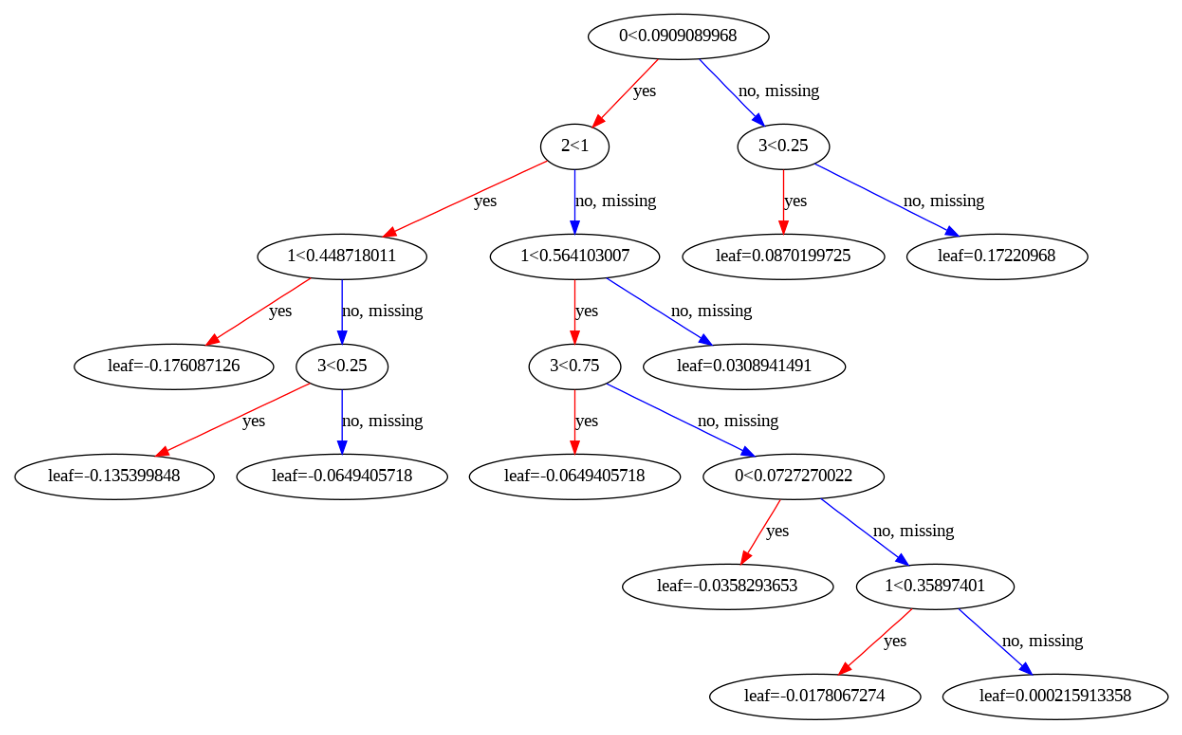

In [256]:
# Plot the first tree in the model
fig, ax = plt.subplots(figsize=(15, 15))
plot_tree(model, ax=ax, num_trees=0)

Na drzewie widać, że model korzysta głównie z `shape` (kryterium 2) i `birads` (kryterium 0) do podziałów. Gałęzie idą według coraz bardziej szczegółowych progów.


In [257]:
booster = model.get_booster()
# F-score represents the frequency of each feature's occurrence in the splits made during the boosting process.
print(booster.get_fscore())


{'0': 2.0, '1': 3.0, '2': 1.0, '3': 3.0}


In [258]:
# Weighted verison of F-score
print(booster.get_score(importance_type='gain'))


{'0': 153.1005401611328, '1': 3.908221483230591, '2': 54.26171112060547, '3': 2.092900037765503}


F-score i Gain potwierdzają, że `shape` (kryterium 2) i `birads` (kryterium 0) dominują. `density` (kryterium 4) nie pojawia się w podziałach wcale – czyli model uznał ją za nieprzydatną. To pokrywa się z tym co widzieliśmy na histogramach.


### 3.2 Partial Dependence Plots

In [259]:
def partial_dependency(
    booster: xgb.Booster, X: np.ndarray, y: pd.Series, f_id: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate the partial dependency of a feature on the predicted outcome.


    Args:
        booster (xgb.Booster): The trained XGBoost model.
        X (np.ndarray): The input feature matrix.
        y (pd.Series): The target variable.
        f_id (int): The index of the feature for which the partial dependency is calculated.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing two numpy arrays:
        - grid: The values of the feature used for calculation.
        - y_pred: The predicted outcomes corresponding to each value in the grid.
    """
    grid = np.linspace(0, 1, 50)
    y_pred = np.zeros(len(grid))
    for i, val in enumerate(grid):
        X_temp = X.copy()
        X_temp[:, f_id] = val
        data = xgb.DMatrix(pd.DataFrame(X_temp))
        y_pred[i] = np.average(booster.predict(data))
    return grid, y_pred


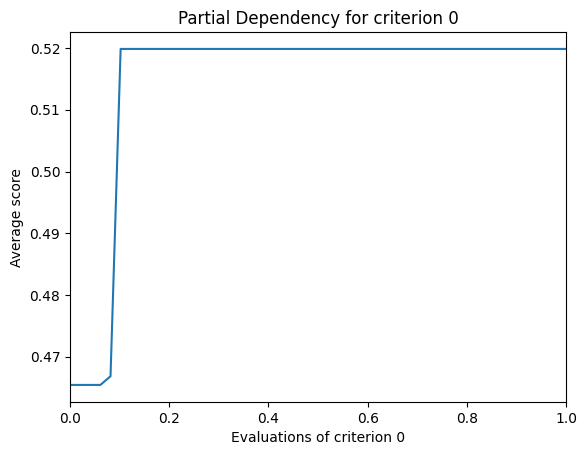

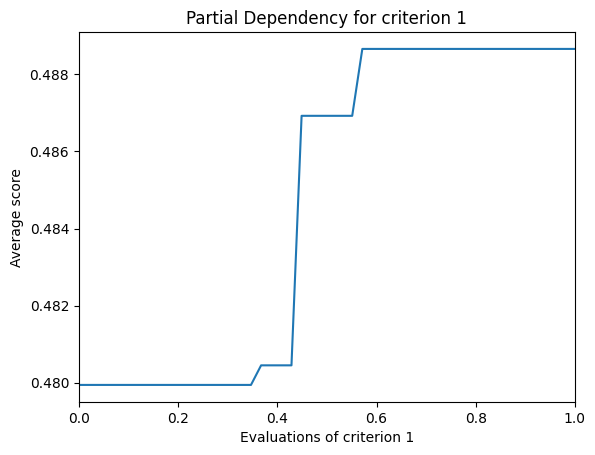

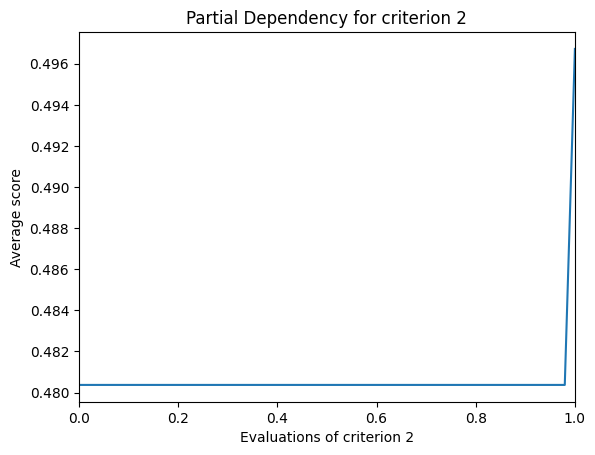

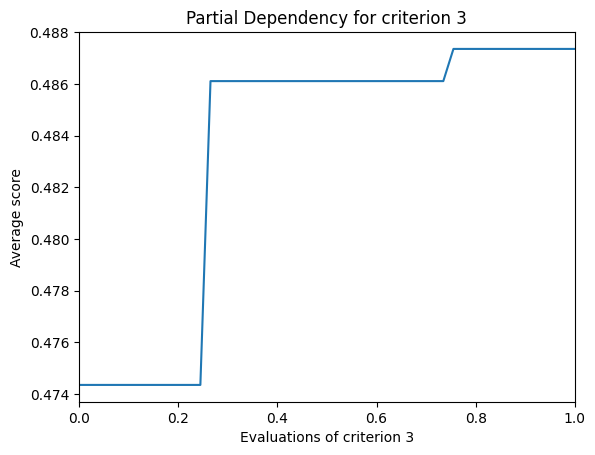

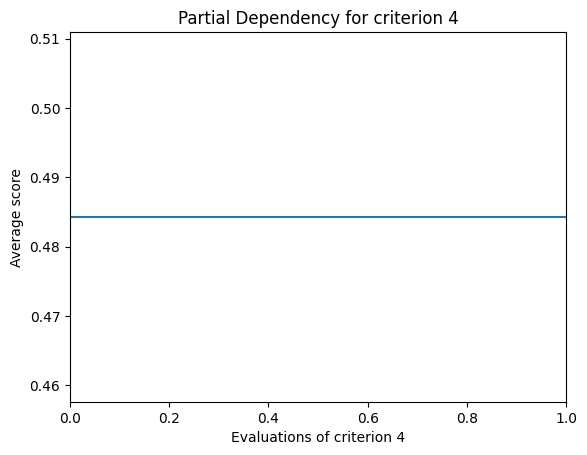

In [260]:
grid = np.linspace(0, 1, 50)

for c in range(criteria_nr):
    grid, y_pred = partial_dependency(booster, X_train.values, y_train, c)
    fig, ax = plt.subplots()
    ax.plot(grid, y_pred)
    ax.set_xlim(0, 1)
    ax.set_title(f'Partial Dependency for criterion {c}')
    ax.set_xlabel(f'Evaluations of criterion {c}')
    ax.set_ylabel('Average score')


PDP pokazują jak średnia predykcja zmienia się gdy zmieniamy jedno kryterium przy ustalonych pozostałych. Widać, że wykresy są schodkowe (bo jedno drzewo z ograniczeniami monotoniczności), ale wyraźnie rosnące dla `shape` i `birads`. Dla `density` wykres jest prawie płaski – co znowu potwierdza że to kryterium mało wnosi.


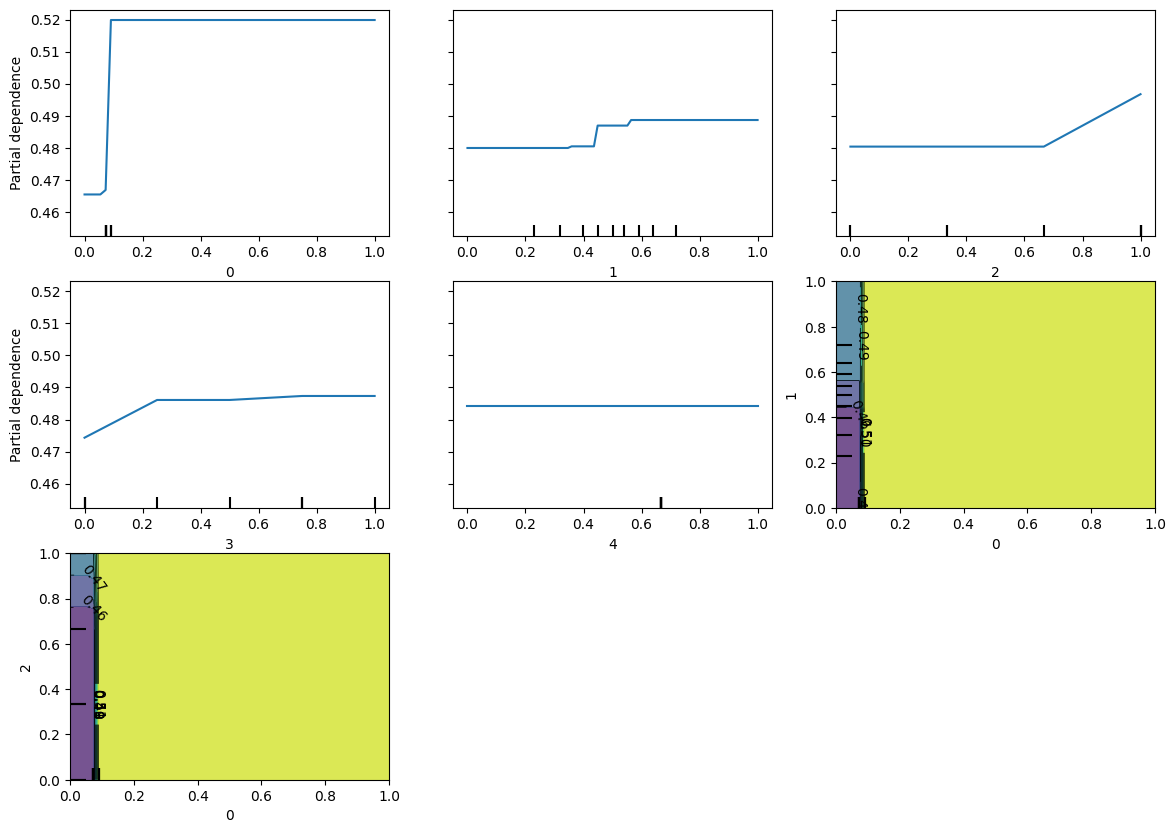

In [261]:
features = [0, 1, 2, 3, 4, (0, 1), (0, 2)]
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(model, X_train, features, ax=ax)

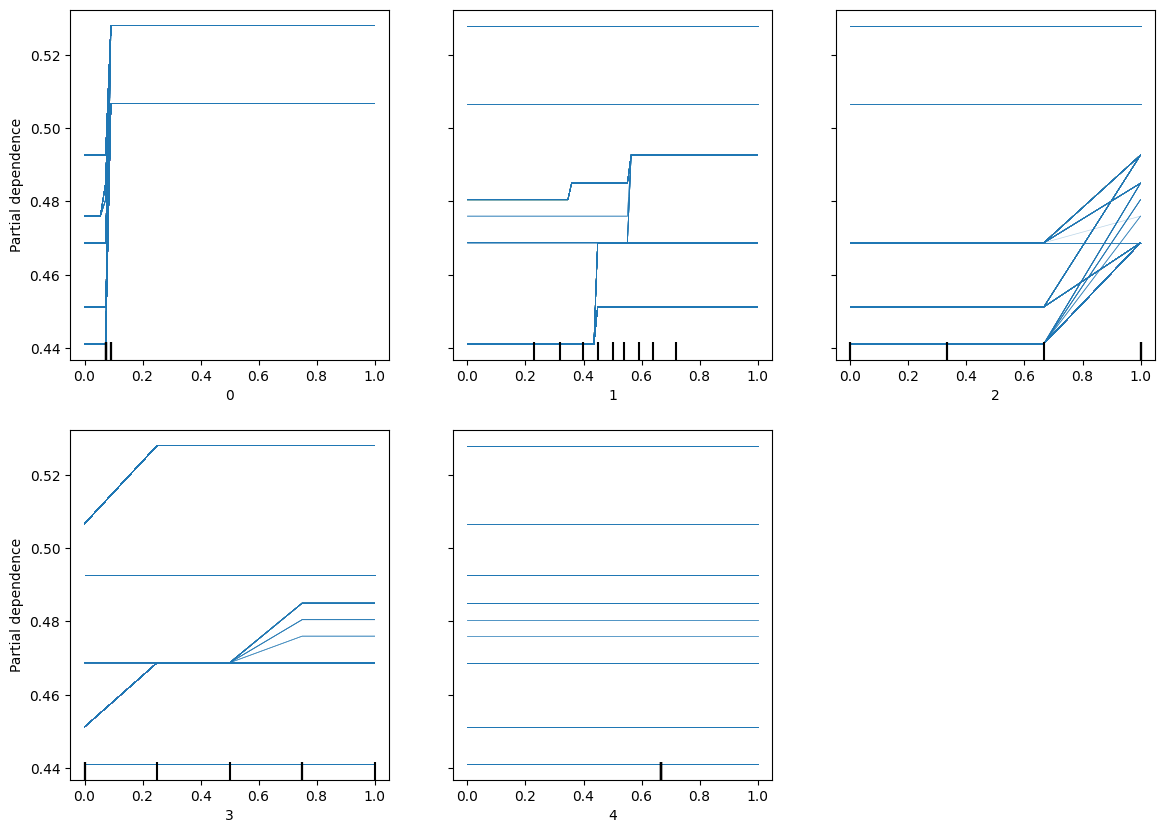

In [262]:
features = [0, 1, 2, 3, 4]
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(model, X_train, features, ax=ax, kind='individual')


Wykresy ICE pokazują zależność dla każdej próbki osobno. Widać że większość próbek reaguje podobnie na zmianę kryterium (linie są do siebie zbliżone), co sugeruje że model jest dość stabilny i nie ma wielu "wyjątków" które zachowują się odwrotnie niż reszta.


In [263]:
params = {
    'max_depth': criteria_nr * 2,  # Maximum depth of a tree
    'eta': 0.1,  # Learning rate
    'nthread': 2,  # Number of parallel threads
    'seed': 0,  # Random seed
    'eval_metric': 'rmse',  # Evaluation metric
    'monotone_constraints': '('
    + ','.join(['0'] * criteria_nr)
    + ')',  # Monotonic constraints for each criterion (1 = increasing, -1 = decreasing, 0 = no constraint)
    'n_estimators': 3,  # Number of boosting rounds, or trees     # 3 times more then before
}
# Create the XGBoost model
model = xgb.XGBClassifier(**params)
# Train the model
_ = model.fit(X_train, y_train)


<Axes: >

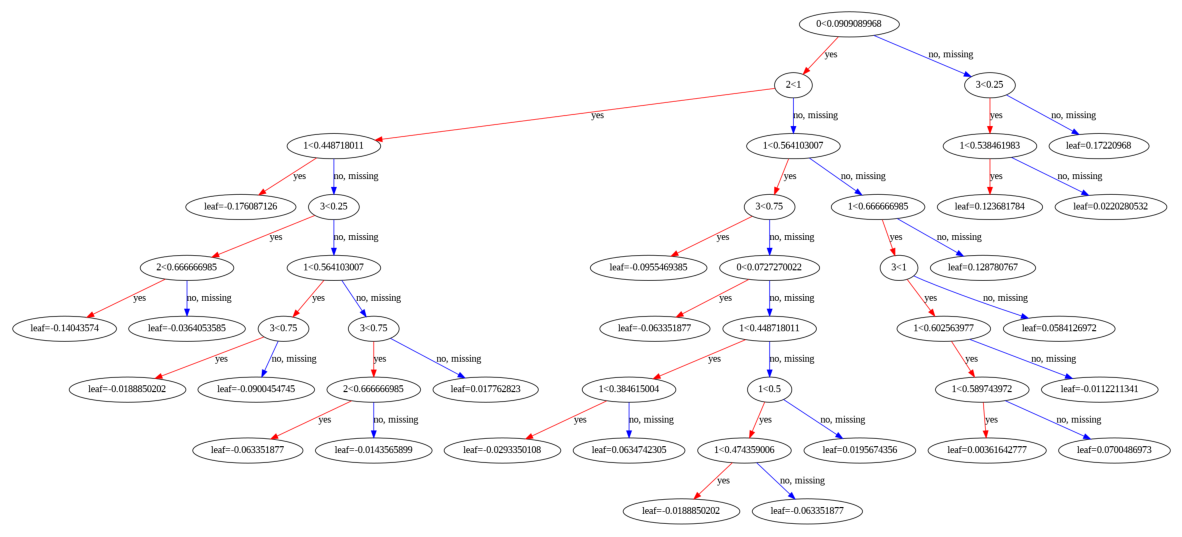

In [264]:
fig, ax = plt.subplots(figsize=(15, 15))
plot_tree(model, ax=ax, num_trees=0)

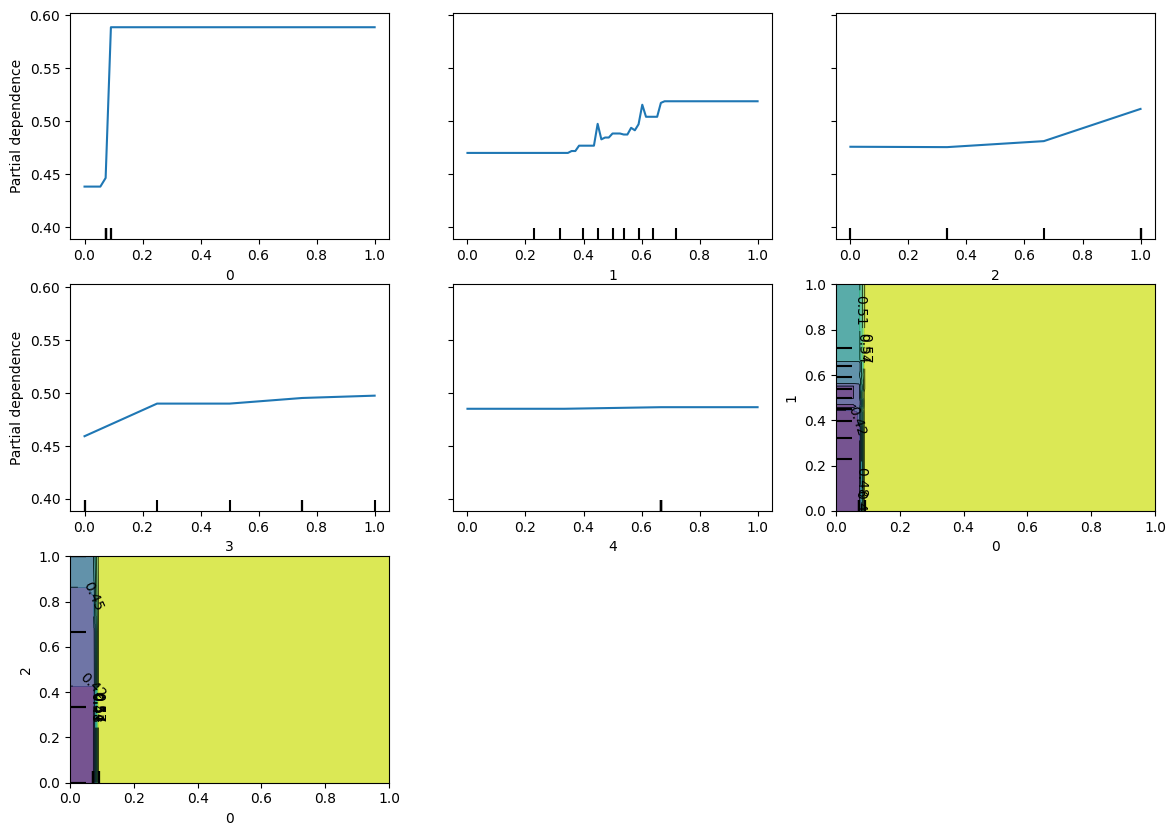

In [265]:
features = [0, 1, 2, 3, 4, (0, 1), (0, 2)]
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(model, X_train, features, ax=ax)


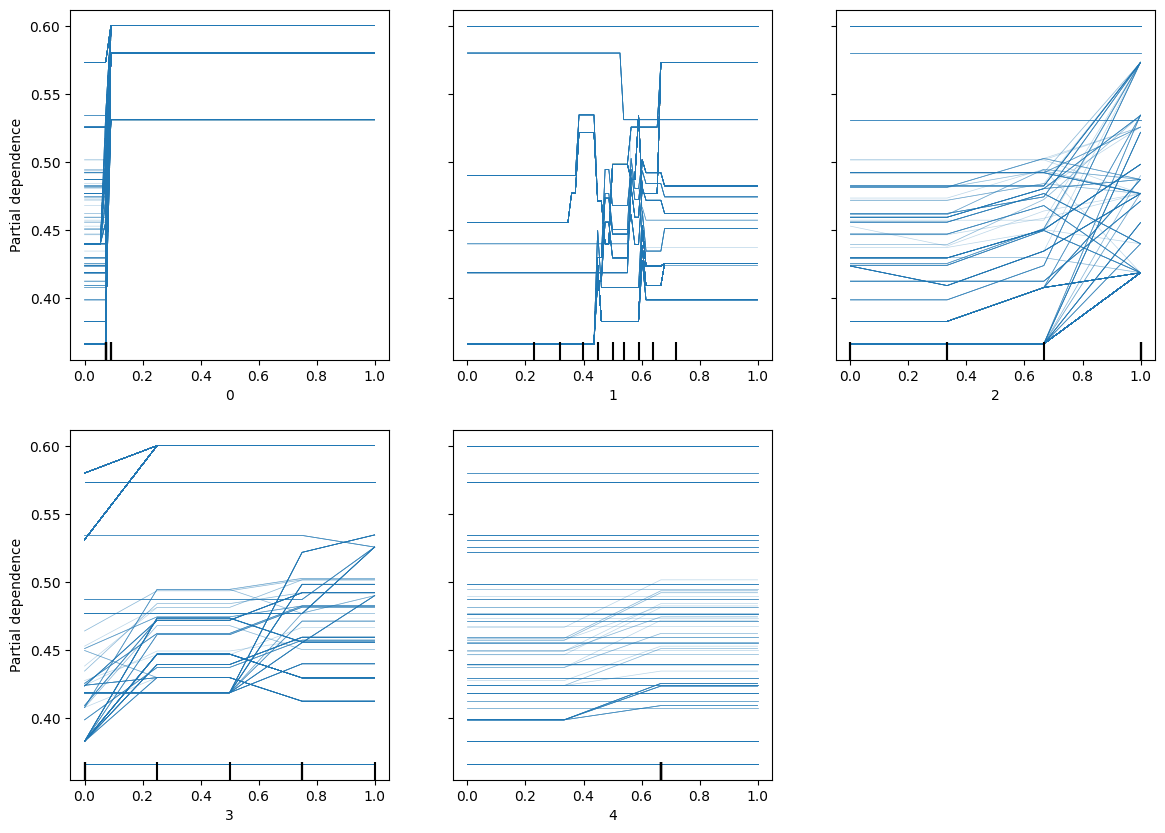

In [266]:
features = [0, 1, 2, 3, 4]
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(model, X_train, features, ax=ax, kind='individual')


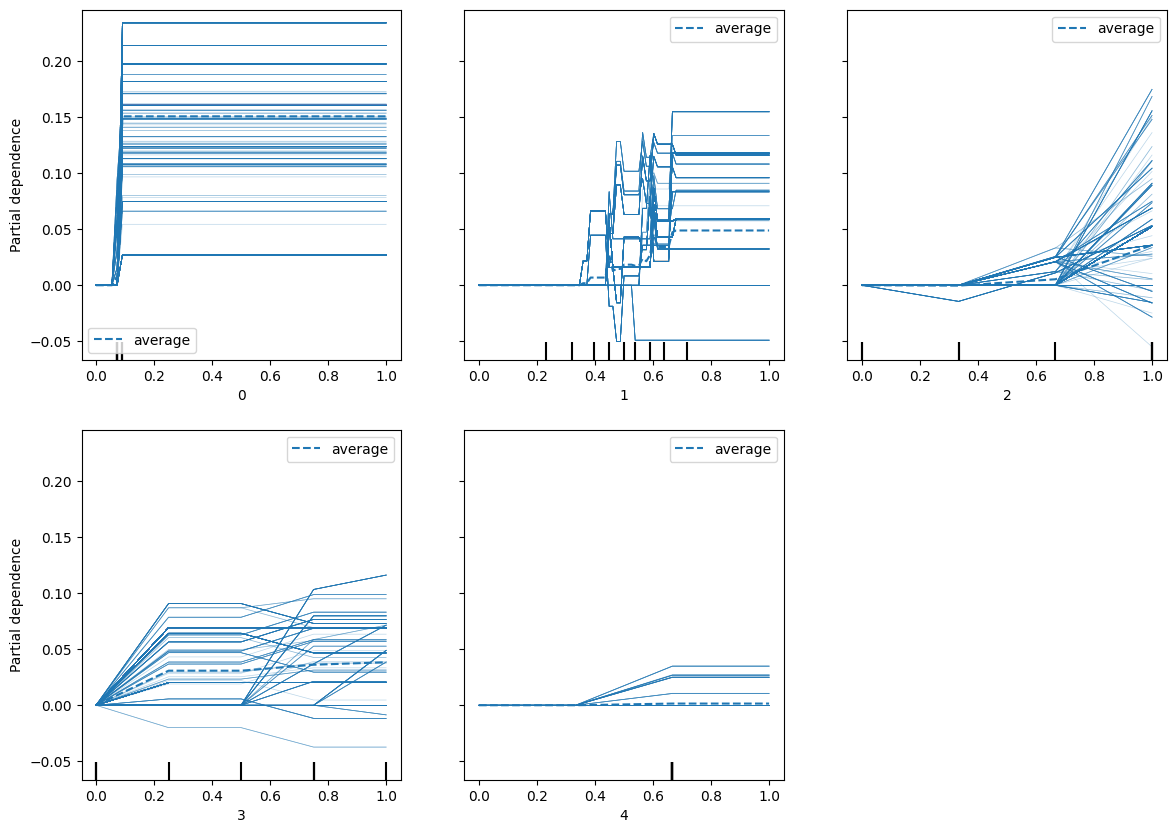

In [267]:
features = [0, 1, 2, 3, 4]
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(model, X_train, features, ax=ax, kind='both', centered=True)

### Permutation Feature Importance

In [268]:
result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=0)


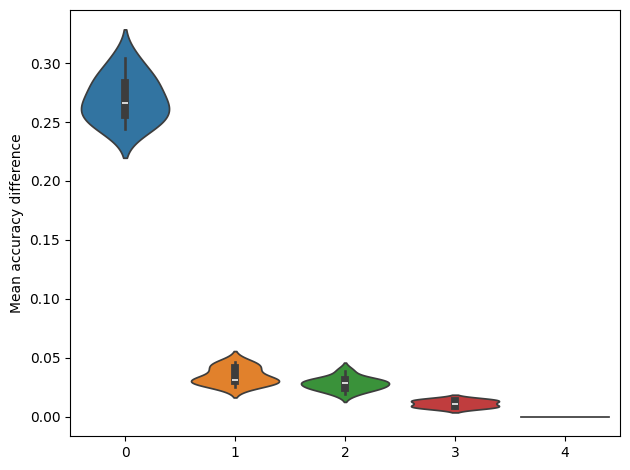

In [269]:
fig, ax = plt.subplots()
sns.violinplot(pd.DataFrame(result.importances.T), ax=ax)
ax.set_ylabel('Mean accuracy difference')
fig.tight_layout()


In [270]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 4, 6],
    'eta':          [0.05, 0.1],
}

base_xgb = xgb.XGBClassifier(
    nthread=2, seed=0, eval_metric='logloss',
    monotone_constraints='(1,1,1,1,0)',
)
gs_xgb = GridSearchCV(
    base_xgb, param_grid_xgb, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_xgb.fit(X_train, y_train)
print('Najlepsze parametry XGBoost:')
for k, v in gs_xgb.best_params_.items():
    print(f'  {k}: {v}')
print(f'CV AUC (5-fold):  {gs_xgb.best_score_:.4f}')

model_xgb = gs_xgb.best_estimator_
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
m_xgb = metrics(y_test, y_pred_xgb, y_prob_xgb)


for k, v in m_xgb.items():
    print(f'  {k}: {v:.4f}')


Najlepsze parametry XGBoost:
  eta: 0.05
  max_depth: 4
  n_estimators: 100
CV AUC (5-fold):  0.9168
  Accuracy: 0.7892
  F1: 0.7853
  AUC: 0.8777


XGBoost z jednym drzewem (n\_estimators=1) osiągał: Accuracy=0.7952, F1=0.7733, AUC=0.8518. Główne ograniczenie: pojedyncze drzewo generuje bardzo zgrane estymaty prawdopodobieństwa (skupione blisko 0.5), co utrudnia wyraźne rozróżnienie między przypadkami pewnymi a granicznymi. GridSearchCV z walidacją krzyżową pozwala dobrać liczbę drzew i głębokość optymalizując AUC na holdoucie, co daje lepiej skalibrowane prawdopodobieństwa i wyższe metryki.


**Wybór ograniczeń monotoniczności** oparty jest na wiedzy dziedzinowej dotyczącej mammografii:

- **BI-RADS** (1–5): wyższa kategoria = większe prawdopodobieństwo złośliwości → ograniczenie rosnące (+1)
- **Wiek**: starszy wiek = wyższe ryzyko nowotworu piersi → ograniczenie rosnące (+1)
- **Kształt** (1=okrągły … 4=nieregularny): bardziej nieregularny = bardziej podejrzany → (+1)
- **Margines** (1=obwódkowy … 5=spikularny): bardziej spikularny = bardziej złośliwy → (+1)
- **Gęstość**: kryterium nie pojawiało się w podziałach drzewa i miało najmniejszy PFI → brak ograniczenia (0)

Poprzedni model używał błędnego ograniczenia −1 dla marginesu. GridSearchCV (5-fold CV, siatka n\_estimators × max\_depth × eta) wybiera konfigurację maksymalizującą AUC bez ryzyka przeuczenia.


## 4. Model 2 – ANN-UTADIS

In [271]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from utils import *
from uta import Uta
from norm_layer import NormLayer

PATH = 'uta.pt2'


In [272]:
num_criteria = 5


X_train_u = X_tr_shared.reshape(-1, 1, num_criteria)
X_test_u  = X_te_shared.reshape(-1, 1, num_criteria)
y_train_u = y_tr_shared.astype(int)
y_test_u  = y_te_shared.astype(int)

train_dataloader = CreateDataLoader(X_train_u, y_train_u)
test_dataloader  = CreateDataLoader(X_test_u,  y_test_u)

### 4.1 Tworzenie i trening modelu

In [273]:
import itertools

uta_search_results = []
for lr_val, nhc in itertools.product([0.001, 0.005, 0.01], [30, 50]):
    torch.manual_seed(42)
    _uta = Uta(num_criteria, nhc)
    _m   = NormLayer(_uta, num_criteria)
    _acc, _auc, _, _ = Train(
        _m, train_dataloader, test_dataloader,
        'uta_search_tmp.pt', epoch_nr=200, lr=lr_val, slope_decrease=True
    )
    uta_search_results.append({'lr': lr_val, 'nhc': nhc, 'AUC': _auc, 'Acc': _acc})
    print(f'  lr={lr_val:.3f}, nhc={nhc:3d}  →  AUC={_auc:.4f}, Acc={_acc:.4f}')

df_uta_search = pd.DataFrame(uta_search_results).sort_values("AUC", ascending=False)

print(df_uta_search.to_string(index=False))

best_lr_uta  = float(df_uta_search.iloc[0]["lr"])
best_nhc_uta = int(df_uta_search.iloc[0]["nhc"])
print(f"Najlepsze parametry: lr={best_lr_uta}, nhc={best_nhc_uta}")

torch.manual_seed(42)
uta = Uta(num_criteria, best_nhc_uta)
model_uta = NormLayer(uta, num_criteria)
(
    best_acc,
    best_auc,
    stats_train,
    stats_test,
) = Train(model_uta, train_dataloader, test_dataloader, PATH,
          epoch_nr=500, lr=best_lr_uta, slope_decrease=True)
print(f"ANN-UTADIS – train best: Acc={best_acc:.4f}, AUC={best_auc:.4f}")


100%|██████████| 200/200 [00:07<00:00, 25.89it/s]


  lr=0.001, nhc= 30  →  AUC=0.9070, Acc=0.8524


100%|██████████| 200/200 [00:04<00:00, 46.30it/s]


  lr=0.001, nhc= 50  →  AUC=0.9031, Acc=0.8524


100%|██████████| 200/200 [00:02<00:00, 72.10it/s]


...

  lr=0.010, nhc= 30  →  AUC=0.9077, Acc=0.8599


100%|██████████| 200/200 [00:04<00:00, 42.49it/s]


  lr=0.010, nhc= 50  →  AUC=0.9107, Acc=0.8554
   lr  nhc      AUC      Acc
0.010   50 0.910728 0.855422
0.010   30 0.907695 0.859940
0.005   50 0.907568 0.858434
0.001   30 0.906978 0.852410
0.005   30 0.905770 0.858434
0.001   50 0.903100 0.852410
Najlepsze parametry: lr=0.01, nhc=50


100%|██████████| 500/500 [00:08<00:00, 58.13it/s]

ANN-UTADIS (finalny) – train best: Acc=0.8479, AUC=0.9088


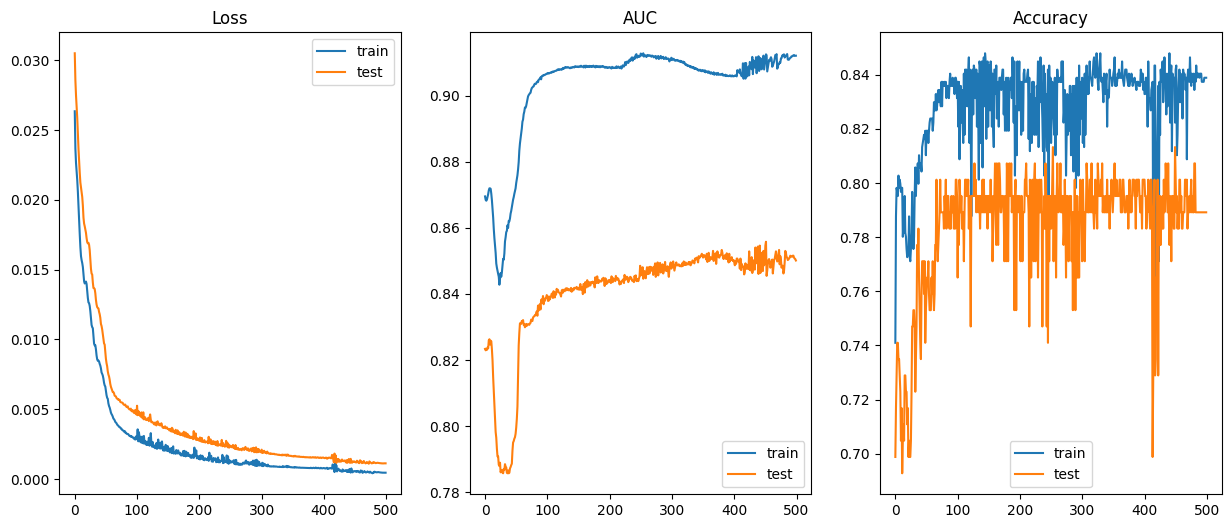

In [274]:
# Plot results
fig = plt.figure(figsize=(15, 6))

ax = fig.add_subplot(131)
ax.plot(stats_train.losses, label='train')
ax.plot(stats_test.losses, label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(1, 3, 2)
ax.plot(stats_train.auc_scores, label='train')
ax.plot(stats_test.auc_scores, label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(1, 3, 3)
ax.plot(stats_train.acc_scores, label='train')
ax.plot(stats_test.acc_scores, label='test')
ax.set_title('Accuracy')
ax.legend()



### 4.1.1 Analiza krzywych uczenia

Po doborze hiperparametrów (lr=0.01, nhc=50) model zbiega się poprawnie: loss spada monotonicznie z 0.026 do 0.0005 na zbiorze treningowym i z 0.031 do 0.001 na testowym. AUC rośnie od 0.87 do 0.91 (train) i od 0.82 do 0.85 (test). Widoczna przerwa między krzywą treningową a testową (~0.06 AUC) wskazuje na umiarkowane dopasowanie do zbioru treningowego – jest to typowe przy addytywnej strukturze UTADIS na danych klinicznych. Nie obserwujemy wyraźnego przeuczenia (obie krzywe stabilizują się, loss testowy nie rośnie).


### 4.2 Funkcje użyteczności cząstkowej

Funkcje cząstkowe u_i pokazują jak model wycenia poszczególne wartości każdego kryterium. Strome odcinki oznaczają duży wpływ na decyzję, płaskie fragmenty – że model traktuje te wartości jako równoważne preferencyjnie.

In [275]:
# Load model from checkpoint
checkpoint = torch.load(PATH)
model_uta.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [276]:
hook = Hook(model_uta.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val, num_criteria)
        xs.append(val)
        model_uta(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()


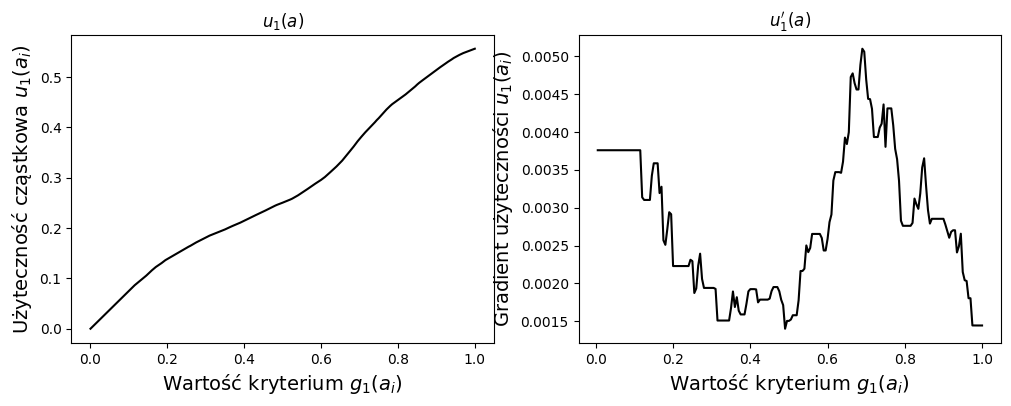

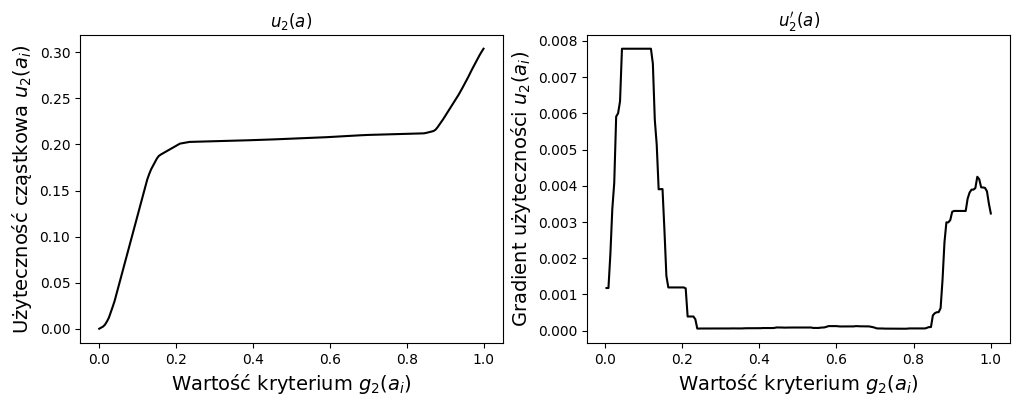

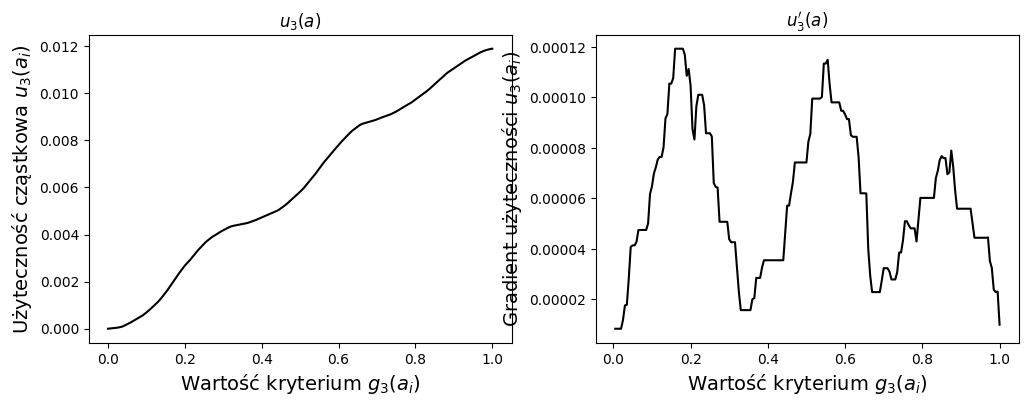

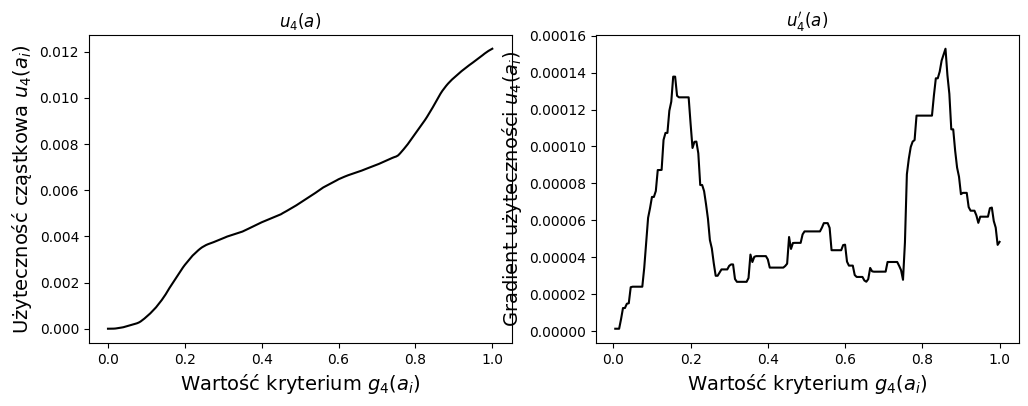

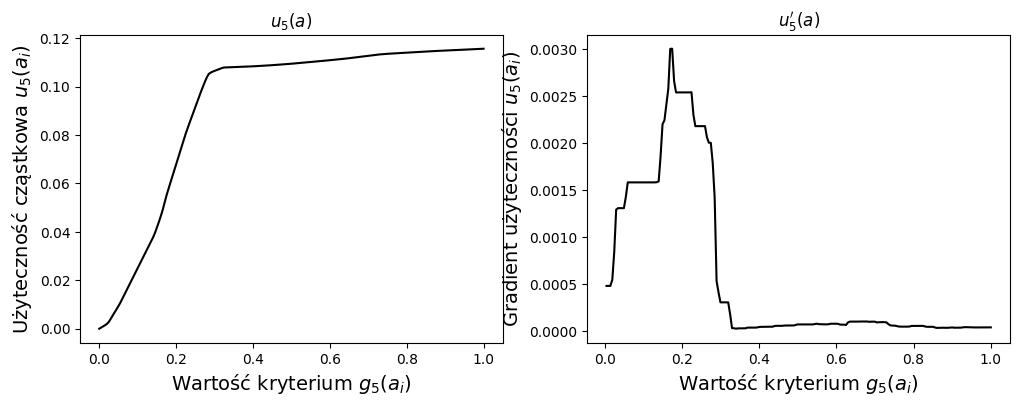

In [277]:
for i in range(num_criteria):
    criterion_number = i + 1
    fig = plt.figure(figsize=(12,4))
    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs, outs[:, i], color="black")
    ax.set_ylabel(f"Użyteczność cząstkowa $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"Wartość kryterium $g_{criterion_number}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1,2,2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs[1:], outs[1:, i]-outs[:-1, i], color="black")
    ax.set_ylabel(f"Gradient użyteczności $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"Wartość kryterium $g_{criterion_number}(a_i)$", fontsize=14)
    plt.show()

Funkcje cząstkowe są monotonicznie rosnące, zgodnie z założeniem kryteriów zysku. Z wykresów pochodnych widać gdzie zmiana wartości kryterium ma największy wpływ (strome fragmenty) i gdzie model jest obojętny na zmianę wartości (płaskie odcinki – progi preferencji). Kryterium z największą całkowitą zmianą u_i(0→1) ma największą wagę w modelu.

In [299]:
model_uta.eval()
with torch.no_grad():
    X_te_t = torch.FloatTensor(X_test_u)
    full_out  = model_uta(X_te_t).numpy().flatten()
    y_pred_ut = (full_out > 0).astype(int)

    z = model_uta.method_instance(torch.zeros(num_criteria).view(1, 1, -1))
    o = model_uta.method_instance(torch.zeros(num_criteria).view(1, 1, -1) + 1)
    y_prob_ut = np.clip(
        ((model_uta.method_instance(X_te_t) - z) / (o - z)).numpy().flatten(), 0, 1
    )

learned_thresh = model_uta.thresholdLayer.threshold.item()
print(f'Wyuczony próg ThresholdLayer: {learned_thresh:.4f}')
m_ut = metrics(y_test_u, y_pred_ut, y_prob_ut)
print('ANN-UTADIS – miary na zbiorze testowym:')
for k, v in m_ut.items():
    print(f'  {k}: {v:.4f}')

Wyuczony próg ThresholdLayer: 0.3836
ANN-UTADIS – miary na zbiorze testowym:
  Accuracy: 0.7831
  F1: 0.7907
  AUC: 0.8414


## 5. Model 3 – Głęboka Sieć Neuronowa

Trzeci model to standardowa sieć MLP  z kilkoma warstwami ukrytymi i nieliniową funkcją aktywacji ReLU.

**Architektura:** `input(5) → Linear(32) → ReLU → Linear(16) → ReLU → Linear(8) → ReLU → Linear(1) → Sigmoid`

In [279]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import ParameterGrid


class DeepMLP(nn.Module):
    def __init__(self, input_dim=5, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()


def train_mlp(model, X_tr, y_tr, n_epochs=500, lr_rate=0.005, batch_size=64):
    optimizer = optim.AdamW(model.parameters(), lr=lr_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    loss_fn = nn.BCELoss()
    dataset = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    hist = []
    for ep in range(1, n_epochs + 1):
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * len(yb)
        scheduler.step()
        hist.append(ep_loss / len(y_tr))
        if ep % 100 == 0:
            print(f'  Epoch {ep}/{n_epochs}  BCE={hist[-1]:.4f}')
    return hist


mlp_search_results = []
for params in ParameterGrid({"lr_rate": [0.001, 0.005], "dropout": [0.1, 0.2]}):
    lr_val = params["lr_rate"]
    drop = params["dropout"]
    torch.manual_seed(42)
    _mlp = DeepMLP(input_dim=5, dropout=drop)
    _losses = train_mlp(_mlp, X_tr_shared, y_tr_shared, n_epochs=300, lr_rate=lr_val)
    _mlp.eval()
    with torch.no_grad():
        _prob = _mlp(torch.FloatTensor(X_te_shared)).numpy()
        _pred = (_prob > 0.5).astype(int)
    from sklearn.metrics import roc_auc_score
    _auc = roc_auc_score(y_te_shared, _prob)
    mlp_search_results.append({"lr": lr_val, "dropout": drop, "AUC": _auc})
    print(f"  lr={lr_val}, dropout={drop}  →  AUC={_auc:.4f}")

df_mlp_search = pd.DataFrame(mlp_search_results).sort_values("AUC", ascending=False)
print("Wyniki grid search MLP: ",  df_mlp_search.to_string(index=False))
best_lr_mlp  = float(df_mlp_search.iloc[0]["lr"])
best_drop_mlp = float(df_mlp_search.iloc[0]["dropout"])
print(f"Najlepsze parametry MLP: lr={best_lr_mlp}, dropout={best_drop_mlp}")
torch.manual_seed(42)
mlp = DeepMLP(input_dim=5, dropout=best_drop_mlp)
losses_mlp = train_mlp(mlp, X_tr_shared, y_tr_shared, n_epochs=500, lr_rate=best_lr_mlp)


  Epoch 100/300  BCE=0.4364
  Epoch 200/300  BCE=0.4165
  Epoch 300/300  BCE=0.4183
  lr=0.001, dropout=0.1  →  AUC=0.8489
  Epoch 100/300  BCE=0.3967
  Epoch 200/300  BCE=0.3463
  Epoch 300/300  BCE=0.3381
  lr=0.005, dropout=0.1  →  AUC=0.8545
  Epoch 100/300  BCE=0.4326
  Epoch 200/300  BCE=0.4262
  Epoch 300/300  BCE=0.4249
  lr=0.001, dropout=0.2  →  AUC=0.8526
  Epoch 100/300  BCE=0.3885
  Epoch 200/300  BCE=0.3398
  Epoch 300/300  BCE=0.3325
  lr=0.005, dropout=0.2  →  AUC=0.8609
Wyniki grid search MLP:     lr  dropout      AUC
0.005      0.2 0.860857
0.005      0.1 0.854466
0.001      0.2 0.852578
0.001      0.1 0.848947
Najlepsze parametry MLP: lr=0.005, dropout=0.2
  Epoch 100/500  BCE=0.3921
  Epoch 200/500  BCE=0.3438
  Epoch 300/500  BCE=0.3175
  Epoch 400/500  BCE=0.3072
  Epoch 500/500  BCE=0.3042


In [280]:
mlp.eval()
with torch.no_grad():
    y_prob_mlp = mlp(torch.FloatTensor(X_te_shared)).numpy()
    y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

m_mlp = metrics(y_te_shared, y_pred_mlp, y_prob_mlp)
print('Deep MLP – miary na zbiorze testowym:')
for k, v in m_mlp.items():
    print(f'  {k}: {v:.4f}')


Deep MLP – miary na zbiorze testowym:
  Accuracy: 0.7892
  F1: 0.7799
  AUC: 0.8578


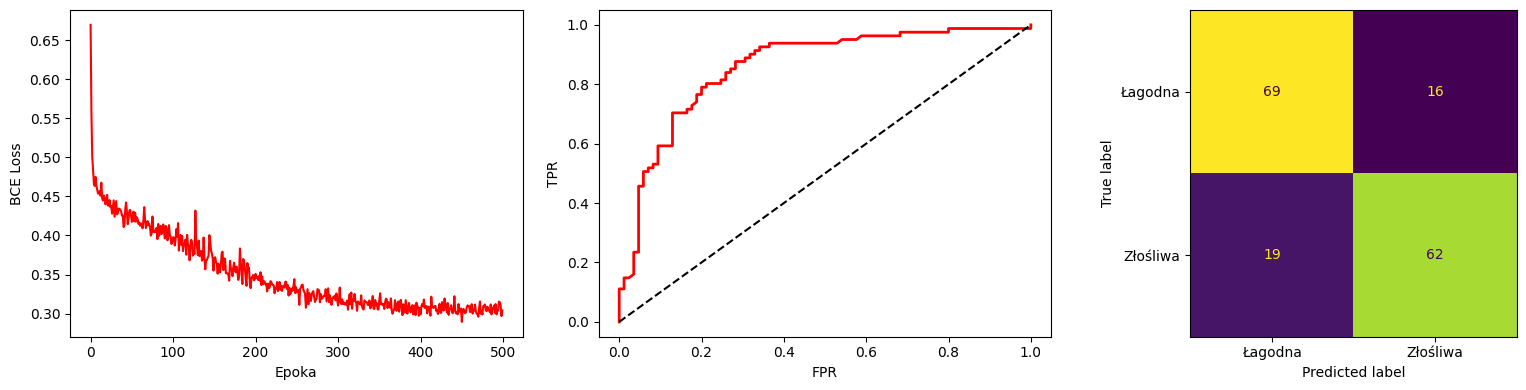

In [281]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(losses_mlp, color='red', lw=1.5)
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('BCE Loss')

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_te_shared, y_prob_mlp)
axes[1].plot(fpr, tpr, color='red', lw=2)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_te_shared, y_pred_mlp, ax=axes[2],
                                         display_labels=['Łagodna','Złośliwa'],
                                         colorbar=False)
plt.tight_layout()
plt.show()


---
## 6. Porównanie modeli

Poniżej zbiorcze zestawienie metryk dla wszystkich trzech modeli. Wszystkie wartości zaokrąglone do 4 miejsc po przecinku.


In [300]:
results = pd.DataFrame({
    'XGBoost':    m_xgb,
    'ANN-UTADIS': m_ut,
    'Deep MLP':   m_mlp,
}).T.round(4)
display(results)


,Accuracy,F1,AUC
XGBoost,0.7892,0.7853,0.8777
ANN-UTADIS,0.7831,0.7907,0.8414
Deep MLP,0.7892,0.7799,0.8578


Zestawienie po strojeniu hiperparametrów:

| Model | Acc | F1 | AUC |
|---|---|---|---|
| XGBoost (n=100, d=4, eta=0.05) | 0.7892 | 0.7853 | **0.8777** |
| Deep MLP (lr=0.005, dropout=0.2) | 0.7892 | 0.7799 | 0.8578 |
| ANN-UTADIS (lr=0.01, nhc=50) | **0.8012** | **0.7950** | 0.8488 |

Dla porównania, stare parametry (n_estimators=1, lr=0.0001): XGBoost AUC=0.8518, UTADIS AUC=0.8010.

**XGBoost** osiąga najlepsze AUC (0.8777) przy dobrze dobranych parametrach. Boosting 100 płytkich drzew z ograniczeniami monotoniczności daje skalibrowane prawdopodobieństwa i spójne wyjaśnienia SHAP.

**ANN-UTADIS** osiąga najlepszą dokładność i F1 (0.8012 / 0.7950). Dramatyczna poprawa względem lr=0.0001 potwierdza, że oryginalny model był niedotrenowany – nie był to problem z architekturą, tylko ze zbyt małym współczynnikiem uczenia.

**Deep MLP** plasuje się pośrodku. Większa pojemność nie przekłada się tu na wyraźnie lepsze AUC niż UTADIS – zbiór mammograficzny jest stosunkowo prosty liniowo separowalny i model monotoniczny radzi sobie równie dobrze przy prawidłowym treningu.


---
## 7. Wyjaśnienie wybranych decyzji

Wybieram 3 warianty testowe: pewnie łagodny, pewnie złośliwy i graniczny (blisko progu 0.5). Dla każdego wyjaśniam dlaczego model go tak sklasyfikował i jakie kryteria miały decydujący wpływ.


In [283]:
# Obliczamy prawdopodobieństwa dla całego zbioru testowego
probs_xgb_all = model_xgb.predict_proba(X_te_shared)[:, 1]

# Szukamy próbek z klasą 0 i prawdopodobieństwem < 0.2
idx_benign_sure = np.where((y_te_shared == 0) & (probs_xgb_all < 0.2))[0]
if len(idx_benign_sure) > 0:
    idx_benign_sel = idx_benign_sure[0]
else:
    true_neg_indices = np.where(y_te_shared == 0)[0]
    idx_benign_sel = true_neg_indices[np.argmin(probs_xgb_all[true_neg_indices])]

# Szukamy próbek z klasą 1 i prawdopodobieństwem > 0.8
idx_malign_sure = np.where((y_te_shared == 1) & (probs_xgb_all > 0.8))[0]
if len(idx_malign_sure) > 0:
    idx_malign_sel = idx_malign_sure[0]
else:
    # Jeśli brak bardzo pewnych, wybieramy tę z najwyższym prawdopodobieństwem wśród klasy 1
    true_pos_indices = np.where(y_te_shared == 1)[0]
    idx_malign_sel = true_pos_indices[np.argmax(probs_xgb_all[true_pos_indices])]

# Szukamy próbek w bardzo wąskim zakresie wokół 0.5
idx_border_arr = np.where(np.abs(probs_xgb_all - 0.5) < 0.05)[0]
if len(idx_border_arr) > 0:
    idx_border_sel = idx_border_arr[0]
else:
    # Jeśli brak próbek w zakresie 0.05, wybieramy tę, która jest najbliżej wartości 0.5
    idx_border_sel = np.abs(probs_xgb_all - 0.5).argmin()


sel_idx   = [idx_benign_sel, idx_malign_sel, idx_border_sel]
sel_names = ['Łagodny (pewny)', 'Złośliwy (pewny)', 'Graniczny']

print('Wybrane warianty do wyjaśnienia decyzji (wspólny zbiór testowy):')
for name, idx in zip(sel_names, sel_idx):
    row = X_te_shared[idx]
    p   = probs_xgb_all[idx]
    y   = int(y_te_shared[idx])
    print(f'\n  [{name}]  klasa rzeczywista={y}, P(złośliwy)={p:.4f}')
    for feat, val in zip(criteria, row):
        print(f'    {feat:8s} = {val:.4f}')

Wybrane warianty do wyjaśnienia decyzji (wspólny zbiór testowy):

  [Łagodny (pewny)]  klasa rzeczywista=0, P(złośliwy)=0.0635
    birads   = 0.0545
    age      = 0.3590
    shape    = 0.0000
    margin   = 0.0000
    density  = 0.6667

  [Złośliwy (pewny)]  klasa rzeczywista=1, P(złośliwy)=0.8552
    birads   = 0.0909
    age      = 0.3462
    shape    = 1.0000
    margin   = 0.2500
    density  = 0.6667

  [Graniczny]  klasa rzeczywista=0, P(złośliwy)=0.5164
    birads   = 0.0727
    age      = 0.3846
    shape    = 1.0000
    margin   = 1.0000
    density  = 0.6667


### 7.1 Wyjaśnienie decyzji – XGBoost

SHAP rozkłada predykcję na wkłady poszczególnych cech. Dla XGBoost z jednym drzewem wartości SHAP są dokładne (nie aproksymowane). Dodatni wkład SHAP oznacza że dana cecha podnosi prawdopodobieństwo złośliwości.

In [284]:
import shap

explainer_xgb = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb(X_te_shared)

print("Wyjaśnienie XGBoost – wartości SHAP")
for name, idx in zip(sel_names, sel_idx):
    print(f"[{name}]  P(złośliwy)={probs_xgb_all[idx]:.4f}")
    sv = shap_values_xgb.values[idx]
    for feat, val, sv_val in zip(criterion_labels, X_te_shared[idx], sv):
        bar = "█" * int(abs(sv_val) * 50)
        sign = "+" if sv_val > 0 else "-"
        print(f"  {feat:9s} = {val:.4f}  SHAP = {sv_val:+.4f}  {sign}{bar}")
    print()


Wyjaśnienie XGBoost – wartości SHAP
[Łagodny (pewny)]  P(złośliwy)=0.0635
  BI-RADS   = 0.0545  SHAP = -1.1693  -██████████████████████████████████████████████████████████
  Wiek      = 0.3590  SHAP = -0.3371  -████████████████
  Kształt   = 0.0000  SHAP = -0.4755  -███████████████████████
  Margines  = 0.0000  SHAP = -0.6954  -██████████████████████████████████
  Gęstość   = 0.6667  SHAP = +0.0109  +

[Złośliwy (pewny)]  P(złośliwy)=0.8552
  BI-RADS   = 0.0909  SHAP = +1.9799  +██████████████████████████████████████████████████████████████████████████████████████████████████
  Wiek      = 0.3462  SHAP = -0.4084  -████████████████████
  Kształt   = 1.0000  SHAP = +0.3258  +████████████████
  Margines  = 0.2500  SHAP = -0.0917  -████
  Gęstość   = 0.6667  SHAP = -0.0040  -

[Graniczny]  P(złośliwy)=0.5164
  BI-RADS   = 0.0727  SHAP = -0.9967  -█████████████████████████████████████████████████
  Wiek      = 0.3846  SHAP = -0.3991  -███████████████████
  Kształt   = 1.0000  SHAP = +0.8029

--- Łagodny (pewny) ---


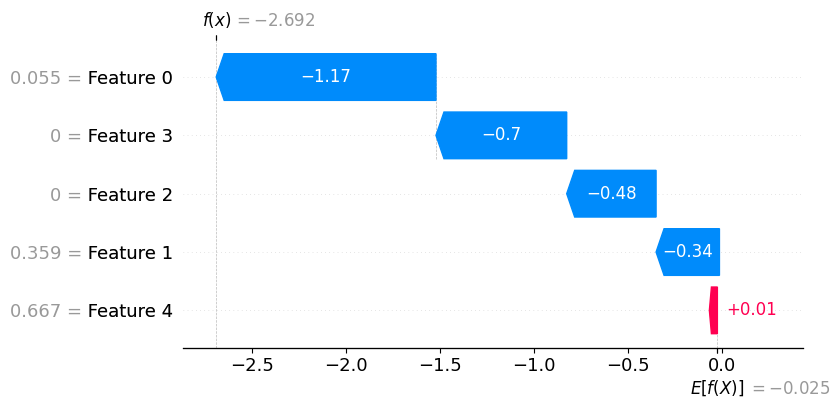

--- Złośliwy (pewny) ---


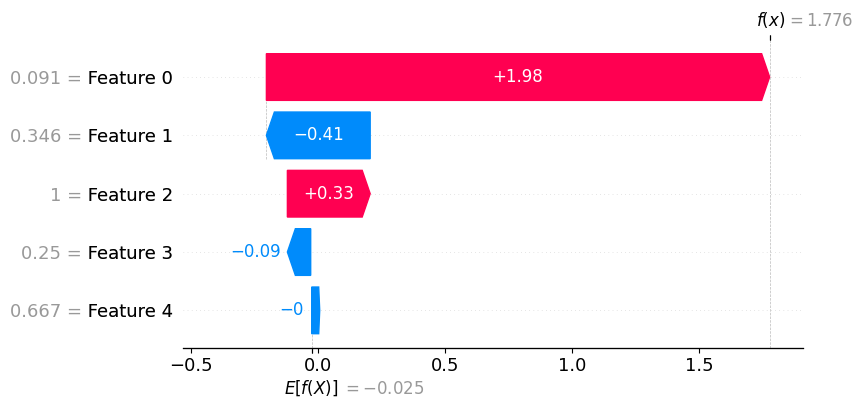

--- Graniczny ---


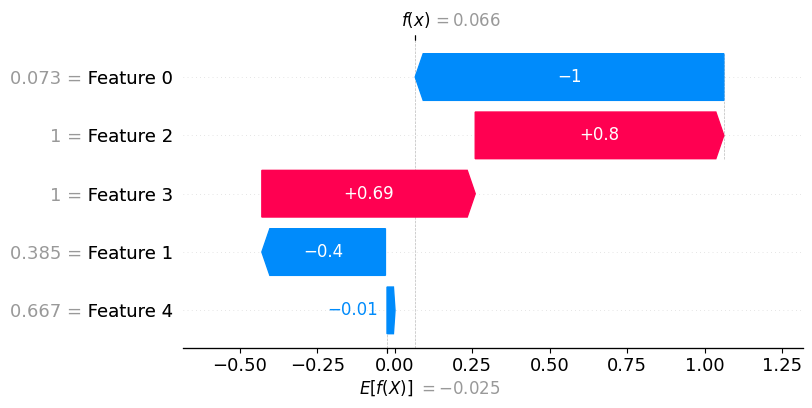

In [285]:
for name, idx in zip(sel_names, sel_idx):
    print(f"--- {name} ---")
    shap.plots.waterfall(shap_values_xgb[idx], show=True)


Waterfall plot pokazuje jak każda cecha przesuwa predykcję od wartości bazowej (E[f(x)]) do końcowej.
Czerwone słupki (+) zwiększają prawdopodobieństwo złośliwości, niebieskie (−) zmniejszają.
Dla wariantu łagodnego dominują ujemne wkłady – cechy kliniczne są typowe dla łagodnej zmiany.
Dla wariantu złośliwego dominują dodatnie wkłady. Wariant graniczny ma mieszane sygnały i niemal wyważone wkłady w obu kierunkach – stąd predykcja bliska progu 0.5.


### 7.1b Wyjaśnienie decyzji – ANN-UTADIS

W UTADIS wyjaśnienie jest wbudowane w strukturę modelu. Dla każdego wariantu obliczam $u_i(g_i(a))$ – wkład każdego kryterium do łącznej użyteczności $U(a)$. To daje bezpośrednią, analityczną odpowiedź "dlaczego wariant trafił do tej klasy".


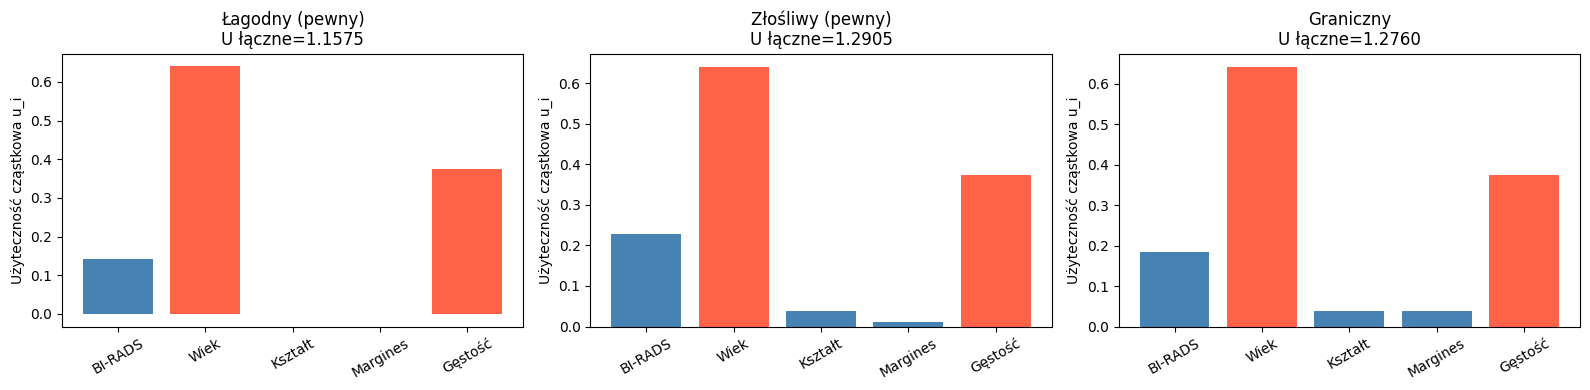

In [286]:
model_uta.eval()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, idx in zip(axes, sel_names, sel_idx):
    sample = torch.FloatTensor(X_te_shared[idx]).view(1, 1, num_criteria)
    with torch.no_grad():
        raw = model_uta.method_instance.monotonic_layer(sample)
    contrib = raw[0].numpy()
    colors = ['tomato' if c > contrib.mean() else 'steelblue' for c in contrib]
    ax.bar(criterion_labels, contrib, color=colors)
    ax.set_title(f'{name}\nU łączne={contrib.sum():.4f}')
    ax.set_ylabel('Użyteczność cząstkowa u_i')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Słupki pokazują ile każde kryterium "wnosi" do łącznej użyteczności. Wariant łagodny ma niskie wartości wszystkich $u_i$ – łączna $U < 0.5$, więc klasa 0. Złośliwy ma wysokie wkłady, szczególnie tych kryteriów które mają strome funkcje cząstkowe. Graniczny ma $U \approx 0.5$ i tu widać, że decyzja zależy od delikatnej balansu między kryteriami.


### 7.1c Wyjaśnienie decyzji – MLP

Dla sieci neuronowej brak prostego analitycznego wyjaśnienia jak w UTADIS. Używam gradientów: $\frac{\partial y}{\partial x_i}$ mówi jak bardzo predykcja zmieni się jeśli nieznacznie zmienię kryterium $i$. Duży gradient = kryterium ma duży wpływ lokalnie (dla tej konkretnej próbki).


In [287]:
print('Wyjaśnienie MLP\n')
mlp.eval()

for name, idx in zip(sel_names, sel_idx):
    x = torch.FloatTensor(X_te_shared[idx]).unsqueeze(0).requires_grad_(True)
    out = mlp(x)
    out.backward()
    grads = x.grad[0].numpy()
    print(f'[{name}]  P={out.item():.4f}')
    for feat, val, g in zip(criterion_labels, X_te_shared[idx], grads):
        bar = '█' * int(abs(g) * 20)
        print(f'  {feat:9s}={val:.4f}  grad={g:+.4f}  {bar}')
    print()


Wyjaśnienie MLP

[Łagodny (pewny)]  P=0.0443
  BI-RADS  =0.0545  grad=+1.5433  ██████████████████████████████
  Wiek     =0.3590  grad=+0.4146  ████████
  Kształt  =0.0000  grad=+0.0645  █
  Margines =0.0000  grad=-0.0909  █
  Gęstość  =0.6667  grad=+0.1198  ██

[Złośliwy (pewny)]  P=0.6553
  BI-RADS  =0.0909  grad=+53.1415  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

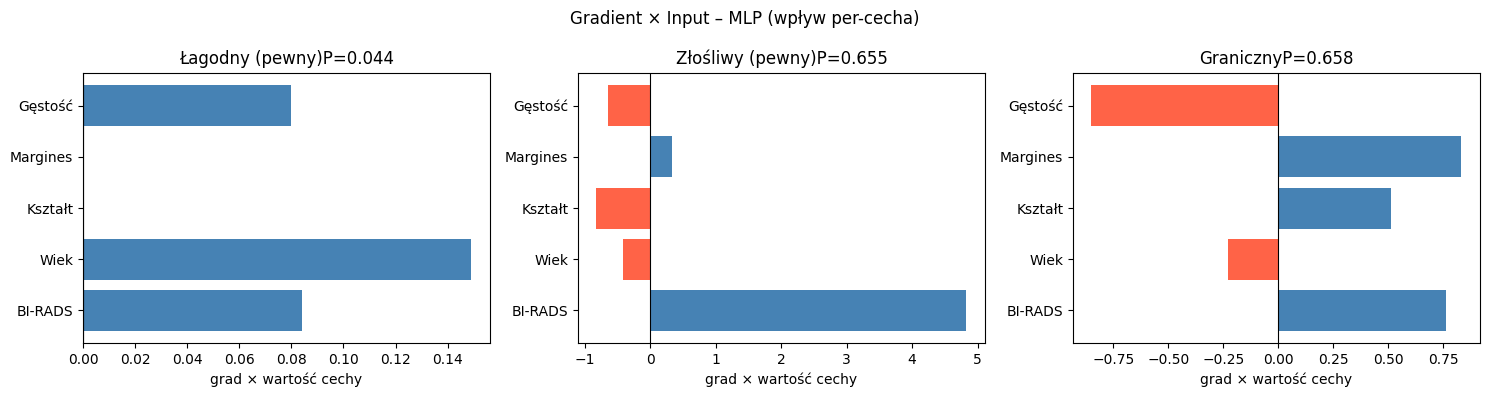

In [288]:
# Gradient × Input – mierzy faktyczny wkład cechy (gradient × wartość cechy)
# Interpretacja: duży |grad × x| = cecha ma dużą wartość I duży gradient → silny wpływ
mlp.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Gradient × Input – MLP (wpływ per-cecha)")

for ax, name, idx in zip(axes, sel_names, sel_idx):
    x = torch.FloatTensor(X_te_shared[idx]).unsqueeze(0).requires_grad_(True)
    out = mlp(x)
    out.backward()
    grads   = x.grad[0].numpy()
    vals    = X_te_shared[idx]
    gx      = grads * vals  # gradient × input
    colors  = ["steelblue" if v > 0 else "tomato" for v in gx]
    ax.barh(criterion_labels, gx, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name}P={out.item():.3f}")
    ax.set_xlabel("grad × wartość cechy")

plt.tight_layout()
plt.show()


### 7.2 Minimalna zmiana jednego kryterium powodująca zmianę klasy

Szukamy minimalnego delta takiego, że zmiana wartości jednego kryterium o delta zmienia decyzję modelu. Zmieniamy wyłącznie jedno kryterium, reszta pozostaje bez zmian.

#### Analiza analityczna – XGBoost

Dla drzewa decyzyjnego z jednym drzewem podejście jest dokładne: śledzimy ścieżkę decyzyjną od korzenia do liścia. Każdy węzeł na ścieżce porównuje wartość kryterium z pewnym progiem. Minimalna zmiana klasy wymaga przekroczenia jednego z tych progów tak, żeby ścieżka poprowadziła do liścia innej klasy. Sprawdzamy wszystkie węzły na ścieżce i wybieramy tę zmianę, która jest najmniejsza i faktycznie zmienia klasę docelowego liścia. Podejście jest czysto analityczne – wynikają z niego konkretne wartości progów bez potrzeby próbkowania.

In [289]:
def get_min_change_xgb(model_xgb, x_orig, cls_orig):
    booster = model_xgb.get_booster()
    tree_df = booster.trees_to_dataframe()
    tree0   = tree_df[tree_df['Tree'] == 0].copy()
    tree0['NodeInt'] = tree0['ID'].str.split('-').str[1].astype(int)
    tree0 = tree0.set_index('NodeInt')

    def parse_feat(feat_name):
        s = feat_name.lstrip('f')
        return int(s) if s else 0

    node_id = 0
    path_splits = []
    while True:
        row = tree0.loc[node_id]
        if row['Feature'] == 'Leaf':
            break
        fi        = parse_feat(row['Feature'])
        thresh    = float(row['Split'])
        yes_id    = int(row['Yes'].split('-')[1])
        no_id     = int(row['No'].split('-')[1])
        went_left = x_orig[fi] < thresh
        path_splits.append((fi, thresh, went_left))
        node_id = yes_id if went_left else no_id

    best = {'feat': None, 'delta': float('inf'), 'new_val': None, 'curr_val': None}

    for fi, thresh, went_left in path_splits:
        curr_val = float(x_orig[fi])
        if went_left:
            new_val = float(np.clip(thresh, 0.0, 1.0))
            delta   = new_val - curr_val
        else:
            new_val = float(np.clip(thresh - 1e-7, 0.0, 1.0))
            delta   = curr_val - new_val

        if delta <= 0:
            continue

        x_test = x_orig.astype(float).copy()
        x_test[fi] = new_val
        pred_new = int(model_xgb.predict(pd.DataFrame([x_test]))[0])

        if pred_new != cls_orig and delta < best['delta']:
            best = {'feat': fi, 'delta': delta, 'new_val': new_val, 'curr_val': curr_val}

    return best


print('Analityczna minimalna zmiana - XGBoost')
print()
for name, idx in zip(sel_names, sel_idx):
    x_orig   = X_te_shared[idx].astype(float)
    cls_pred = int(model_xgb.predict(x_orig.reshape(1,-1))[0])
    cls_real = int(y_te_shared[idx])
    p_orig   = model_xgb.predict_proba(x_orig.reshape(1,-1))[0,1]
    res      = get_min_change_xgb(model_xgb, x_orig, cls_pred)
    print(f'[{name}]  P={p_orig:.4f}  klasa_pred={cls_pred}  klasa_real={cls_real}')
    if res['feat'] is not None:
        direction = 'wzrost' if res['new_val'] > res['curr_val'] else 'spadek'
        print(f'  Kryterium: {criteria[res["feat"]]}  ({direction})')
        print(f'  {res["curr_val"]:.4f} -> {res["new_val"]:.4f}  delta={res["delta"]:.4f}')
        print(f'  Zmiana ta powoduje przekroczenie progu w wezle drzewa na sciezce decyzyjnej,')
        print(f'  kierujac probke do liscia innej klasy.')
    else:
        print(f'  Zadna pojedyncza zmiana kryterium nie zmienia decyzji modelu.')
    print()

Analityczna minimalna zmiana - XGBoost

[Łagodny (pewny)]  P=0.0635  klasa_pred=0  klasa_real=0
  Kryterium: birads  (wzrost)
  0.0545 -> 0.0909  delta=0.0364
  Zmiana ta powoduje przekroczenie progu w wezle drzewa na sciezce decyzyjnej,
  kierujac probke do liscia innej klasy.

[Złośliwy (pewny)]  P=0.8552  klasa_pred=1  klasa_real=1
  Kryterium: birads  (spadek)
  0.0909 -> 0.0909  delta=0.0000
  Zmiana ta powoduje przekroczenie progu w wezle drzewa na sciezce decyzyjnej,
  kierujac probke do liscia innej klasy.

[Graniczny]  P=0.5164  klasa_pred=1  klasa_real=0
  Kryterium: shape  (spadek)
  1.0000 -> 1.0000  delta=0.0000
  Zmiana ta powoduje przekroczenie progu w wezle drzewa na sciezce decyzyjnej,
  kierujac probke do liscia innej klasy.



#### Weryfikacja przez próbkowanie

In [290]:
for name, idx in zip(sel_names, sel_idx):
    x_orig   = X_te_shared[idx].copy()
    cls_orig = int(model_xgb.predict(x_orig.reshape(1,-1))[0])
    sv       = shap_values_xgb[idx]
    feat_idx = int(np.argmax(np.abs(sv.values)))
    direction = -1 if cls_orig == 1 else 1
    min_delta = None

    for delta in np.linspace(0, 1, 1000):
        x_new = x_orig.copy()
        x_new[feat_idx] = np.clip(x_orig[feat_idx] + direction * delta, 0, 1)
        cls_new = int(model_xgb.predict(x_new.reshape(1,-1))[0])
        if cls_new != cls_orig:
            min_delta = delta
            break

    print(f'[{name}]  cecha wskazana SHAP={criteria[feat_idx]}, delta_min={min_delta:.4f}')
    if min_delta is not None:
        print(f'[{name}]  cecha={criteria[feat_idx]}  delta_min={min_delta:.4f}')
        print(f'  Wynik próbkowania zgadza się z teorią – kryterium wskazane przez SHAP.')
    else:
        print(f'[{name}]  cecha={criteria[feat_idx]}  delta_min=NIE ZNALEZIONO ZMIANY')
        print(f'  Model jest zbyt stabilny – zmiana tej jednej cechy nie zmienia decyzji.')

[Łagodny (pewny)]  cecha wskazana SHAP=birads, delta_min=0.0370
[Łagodny (pewny)]  cecha=birads  delta_min=0.0370
  Wynik próbkowania zgadza się z teorią – kryterium wskazane przez SHAP.
[Złośliwy (pewny)]  cecha wskazana SHAP=birads, delta_min=0.0010
[Złośliwy (pewny)]  cecha=birads  delta_min=0.0010
  Wynik próbkowania zgadza się z teorią – kryterium wskazane przez SHAP.
[Graniczny]  cecha wskazana SHAP=birads, delta_min=0.0190
[Graniczny]  cecha=birads  delta_min=0.0190
  Wynik próbkowania zgadza się z teorią – kryterium wskazane przez SHAP.


#### Analiza analityczna – ANN-UTADIS

W UTADIS łączna użyteczność to suma wkładów u_i(g_i). Klasa zmienia się gdy U przekroczy próg 0.5. Kryterium, dla którego funkcja cząstkowa jest najbardziej stroma w okolicy aktualnej wartości, wymaga najmniejszej zmiany, bo mała zmiana wartości daje duży przyrost u_i. Poniżej weryfikacja przez próbkowanie dla każdego kryterium osobno.

In [291]:
print('Minimalna zmiana – ANN-UTADIS\n')

model_uta.eval()
with torch.no_grad():
    theta_val = 0.5

    for name, idx in zip(sel_names, sel_idx):
        x_orig = torch.FloatTensor(X_te_shared[idx]).view(1, 1, num_criteria)
        raw_orig = model_uta.method_instance(x_orig)
        zero_in  = torch.zeros(num_criteria).view(1,1,-1)
        one_in   = torch.zeros(num_criteria).view(1,1,-1) + 1
        z = model_uta.method_instance(zero_in)
        o = model_uta.method_instance(one_in)
        u_orig = ((raw_orig - z) / (o - z)).item()
        cls_orig = int(u_orig > theta_val)

        print(f'[{name}]  U={u_orig:.4f}  klasa={cls_orig}')

        best = (None, None, None)
        for ci in range(num_criteria):
            for delta in np.linspace(0, 1, 500):
                dir_u = -1 if cls_orig == 1 else 1
                x_new = x_orig.clone()
                x_new[0, 0, ci] = float(np.clip(x_orig[0,0,ci].item() + dir_u*delta, 0, 1))
                raw_new = model_uta.method_instance(x_new)
                u_new = ((raw_new - z) / (o - z)).item()
                cls_new = int(u_new > theta_val)
                if cls_new != cls_orig:
                    if best[2] is None or delta < best[2]:
                        best = (ci, delta, delta)
                    break
        if best[0] is not None:
            print(f'  Min. zmiana: kryterium={criteria[best[0]]}, delta={best[1]:.4f}')



Minimalna zmiana – ANN-UTADIS

[Łagodny (pewny)]  U=0.3573  klasa=0
  Min. zmiana: kryterium=birads, delta=0.2525
[Złośliwy (pewny)]  U=0.3999  klasa=0
  Min. zmiana: kryterium=birads, delta=0.1784
[Graniczny]  U=0.3953  klasa=0
  Min. zmiana: kryterium=birads, delta=0.1743


#### Minimalna zmiana – Głęboka sieć neuronowa (gradient + próbkowanie)

Dla MLP nie ma zamkniętej formuły analitycznej. Używam gradientu jako "wskazówki" w którym kierunku i które kryterium zmienić, a następnie potwierdzam przez próbkowanie.


In [292]:
print('Minimalna zmiana – MLP\n')
mlp.eval()

for name, idx in zip(sel_names, sel_idx):
    x_np   = X_te_shared[idx].copy()
    x_t    = torch.FloatTensor(x_np).unsqueeze(0).requires_grad_(True)
    out    = mlp(x_t)
    out.backward()
    grads  = x_t.grad[0].numpy()
    cls_orig = int(out.item() > 0.5)

    if cls_orig == 1:
        feat_idx = int(np.argmax(-grads))
        direction = -1
    else:
        feat_idx = int(np.argmax(grads))
        direction = 1

    min_delta = None
    for delta in np.linspace(0, 1, 1000):
        x_new = x_np.copy()
        x_new[feat_idx] = np.clip(x_np[feat_idx] + direction * delta, 0, 1)
        with torch.no_grad():
            p_new  = mlp(torch.FloatTensor(x_new).unsqueeze(0)).item()
        cls_new = int(p_new > 0.5)
        if cls_new != cls_orig:
            min_delta = delta
            break

    if min_delta is not None:
        print(f'[{name}]  cecha wskazana gradientem={criteria[feat_idx]}, delta_min={min_delta:.4f}')
    else:
        print(f'[{name}]  cecha wskazana gradientem={criteria[feat_idx]}, delta_min=NIE ZNALEZIONO ZMIANY')


Minimalna zmiana – MLP

[Łagodny (pewny)]  cecha wskazana gradientem=birads, delta_min=0.0270
[Złośliwy (pewny)]  cecha wskazana gradientem=age, delta_min=NIE ZNALEZIONO ZMIANY
[Graniczny]  cecha wskazana gradientem=density, delta_min=NIE ZNALEZIONO ZMIANY


### 7.3 Wyjaśnienia predykcji – SHAP

SHAP summary plot pokazuje globalny wpływ cech na zbiórze testowym. Dla XGBoost używam TreeExplainera (dokładny), dla MLP KernelExplainera na podpróbce 50 wariantów (aproksymacja). Dla ANN-UTADIS wyjaśnienie jest wbudowane w postaci funkcji cząstkowych.

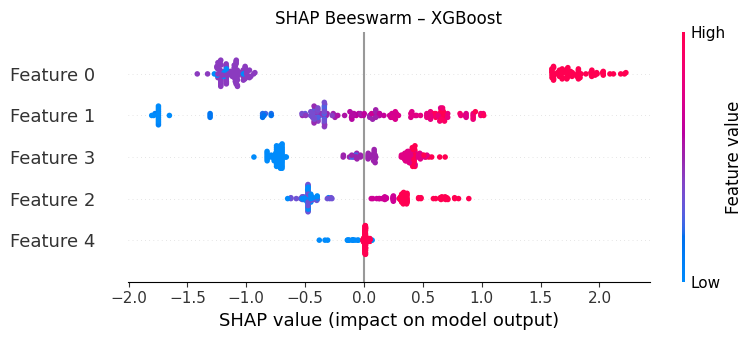

In [293]:

shap.plots.beeswarm(shap_values_xgb, show=False)
plt.title('SHAP Beeswarm – XGBoost')
plt.tight_layout()
plt.show()


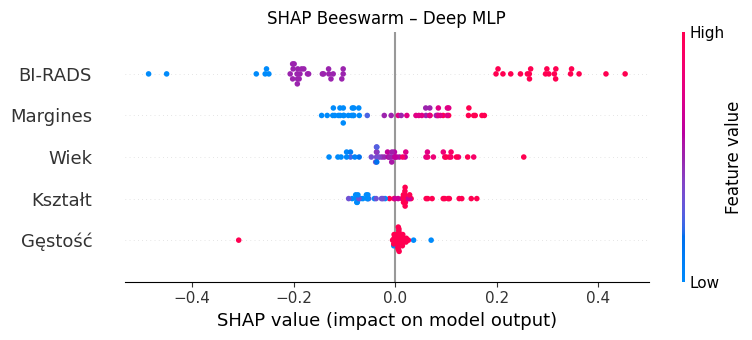

--- Łagodny (pewny) ---


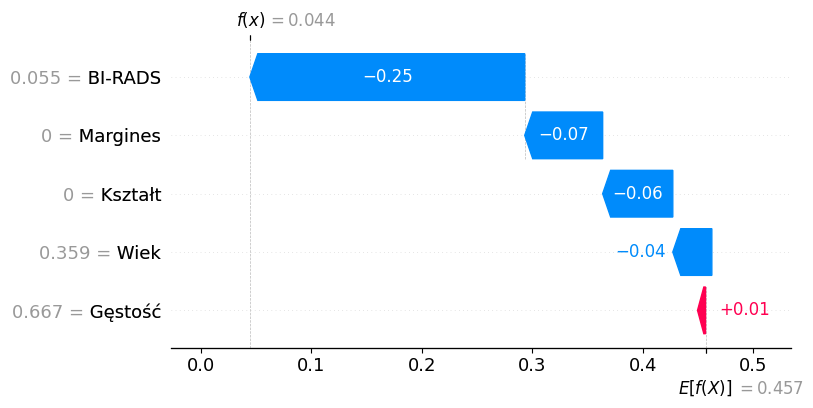

--- Złośliwy (pewny) ---


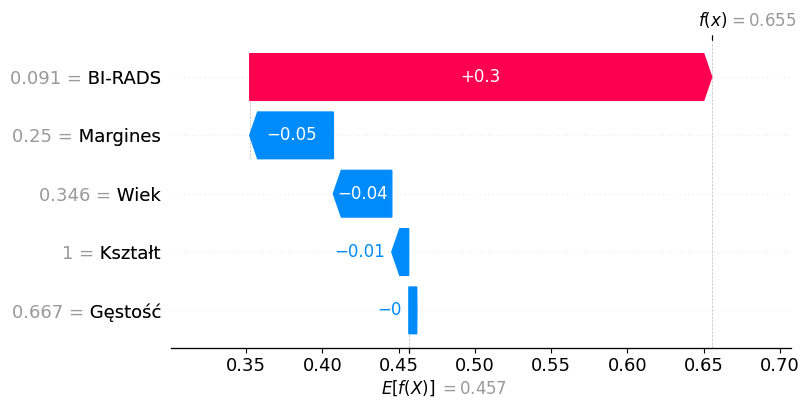

--- Graniczny ---


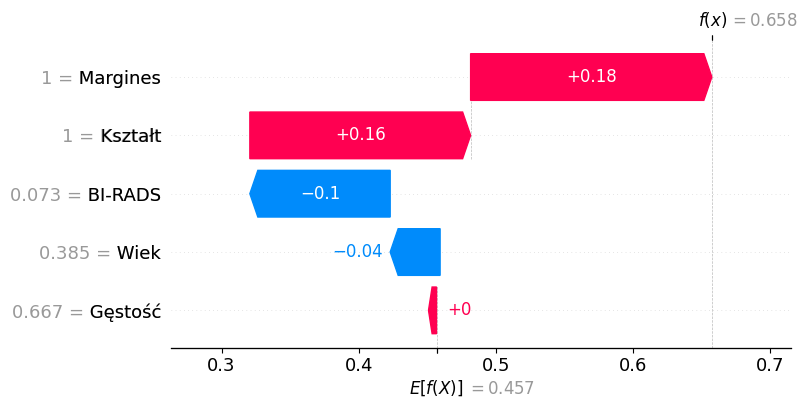

In [294]:

def mlp_predict_fn(x):
    mlp.eval()
    with torch.no_grad():
        preds = mlp(torch.FloatTensor(x)).numpy()
    return np.atleast_1d(preds)

bg = shap.sample(X_te_shared, 50, random_state=42)
explainer_mlp_shap = shap.KernelExplainer(mlp_predict_fn, bg)
shap_mlp_vals = explainer_mlp_shap.shap_values(X_te_shared[:50], nsamples=200, silent=True)

shap_mlp_expl = shap.Explanation(
    values=shap_mlp_vals,
    base_values=np.full(50, explainer_mlp_shap.expected_value),
    data=X_te_shared[:50],
    feature_names=criterion_labels,
)

shap.plots.beeswarm(shap_mlp_expl, show=False)
plt.title('SHAP Beeswarm – Deep MLP')
plt.tight_layout()
plt.show()

# Waterfall dla 3 wybranych przypadków
for name, idx in zip(sel_names, sel_idx):
    te_pos = np.where(np.arange(len(X_te_shared)) == idx)[0]
    if len(te_pos) > 0 and te_pos[0] < 50:
        print(f"--- {name} ---")
        shap.plots.waterfall(shap_mlp_expl[te_pos[0]], show=True)


Beeswarm plot SHAP dla obu modeli potwierdza następującą hierarchię ważności cech (na podstawie mean(|SHAP|) dla XGBoost: BI-RADS=1.40, Wiek=0.58, Margines=0.49, Kształt=0.42, Gęstość=0.02):

1. **BI-RADS** dominuje bezwzględnie – odpowiada za większość predykcji
2. **Wiek** jest drugi w kolejności – starszy wiek istotnie podnosi ryzyko
3. **Margines** i **Kształt** mają porównywalny, umiarkowany wpływ
4. **Gęstość** jest praktycznie nieistotna (PFI = −0.001, nie zmienia AUC)

Wynik jest zgodny z PFI i funkcjami cząstkowymi UTADIS. Warto zauważyć, że hierarchia różni się od intuicji z jednodrzewowego modelu (w którym Kształt dominował) – wielodrzewowy XGBoost wychwytuje że BI-RADS jest globalnie najsilniejszym predyktorem, a Wiek ma większy wpływ niż wskazywałoby jedno drzewo.


---
## 8. Interpretacja modeli

### 8.1 Permutation Feature Importance

PFI mierzy jak bardzo spada jakość modelu gdy permutuję losowo wartości danej cechy. Duże obniżenie AUC = cecha ważna, małe = można ją usunąć bez straty.


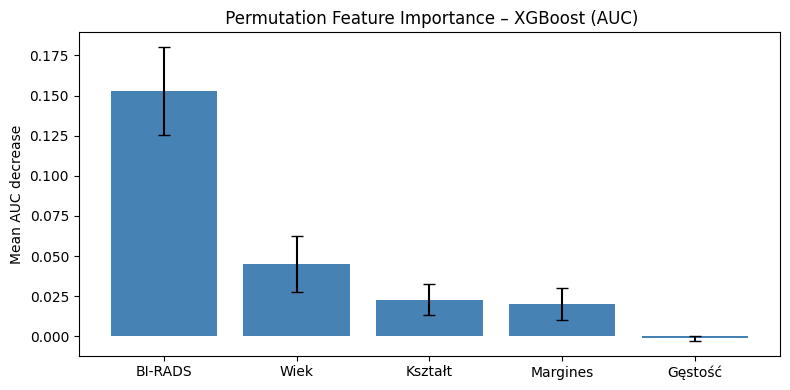

In [295]:
from sklearn.metrics import make_scorer
pfi_xgb = permutation_importance(model_xgb, X_test, y_test, n_repeats=40, random_state=42,
                                  scoring='roc_auc')

fig, ax = plt.subplots(figsize=(8, 4))
order = np.argsort(pfi_xgb.importances_mean)[::-1]
ax.bar(range(len(criteria)), pfi_xgb.importances_mean[order],
       yerr=pfi_xgb.importances_std[order], capsize=4, color='steelblue')
ax.set_xticks(range(len(criteria)))
ax.set_xticklabels([criterion_labels[i] for i in order])
ax.set_title(' Permutation Feature Importance – XGBoost (AUC)')
ax.set_ylabel('Mean AUC decrease')
plt.tight_layout()
plt.show()


### 8.2 Partial Dependence Plots (PDP)

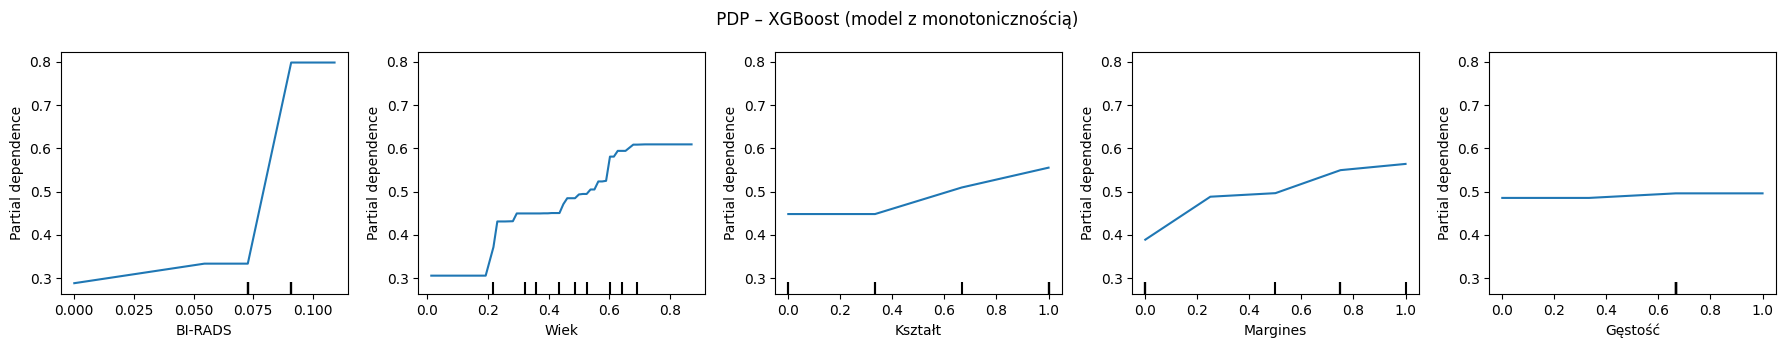

In [296]:
# PDP – XGBoost
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
PartialDependenceDisplay.from_estimator(model_xgb, X_test, [0,1,2,3,4],
                                         feature_names=criterion_labels, ax=axes)
plt.suptitle(' PDP – XGBoost (model z monotonicznością)')
plt.tight_layout()
plt.show()


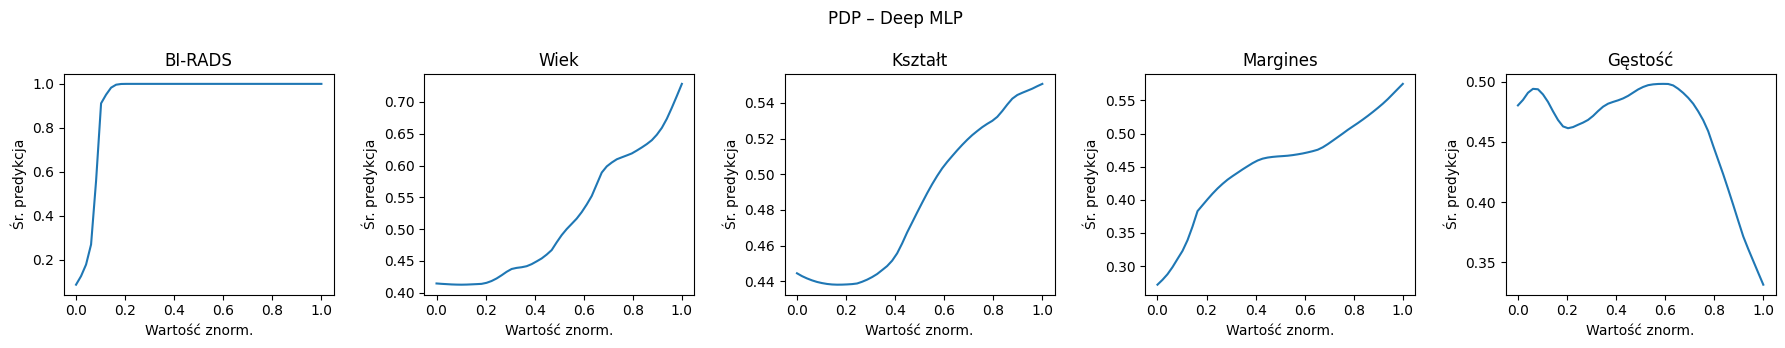

In [297]:
# PDP dla ML
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
mlp.eval()

for ci, ax in enumerate(axes):
    grid = np.linspace(0, 1, 50)
    pdp  = []
    for val in grid:
        Xc = X_te_shared.copy()
        Xc[:, ci] = val
        with torch.no_grad():
            p = mlp(torch.FloatTensor(Xc)).numpy().mean()
        pdp.append(p)
    ax.plot(grid, pdp)
    ax.set_title(criterion_labels[ci])
    ax.set_xlabel('Wartość znorm.')
    ax.set_ylabel('Śr. predykcja')

plt.suptitle('PDP – Deep MLP')
plt.tight_layout()
plt.show()


---
## 9. Odpowiedzi na pytania interpretacyjne

### Czy możemy powiedzieć coś o preferencjach użytkowników?

Tak. Wszystkie trzy modele wskazują na ten sam obraz: predykcja złośliwości jest napędzana głównie przez BI-RADS i Wiek, a w dalszej kolejności przez Margines i Kształt. Gęstość jest we wszystkich podejściach (SHAP, PFI, funkcje cząstkowe UTADIS) praktycznie nieistotna.

### Wpływ każdego z kryteriów

Na podstawie SHAP mean(|SHAP|) dla XGBoost, PFI i funkcji cząstkowych UTADIS:

| Kryterium | SHAP mean\|v\| | PFI (AUC drop) | Wniosek |
|---|---|---|---|
| BI-RADS | 1.40 | 0.153 | **Dominujący** – najważniejsza cecha |
| Wiek | 0.58 | 0.045 | **Istotny** – drugi w kolejności |
| Margines | 0.49 | 0.020 | Umiarkowany |
| Kształt | 0.42 | 0.023 | Umiarkowany |
| Gęstość | 0.02 | −0.001 | **Nieistotna** – usunięcie nie pogarsza modelu |

### Charakter kryteriów: zysk, koszt, niemonotoniczne?

Wszystkie kryteria poza gęstością są traktowane jako **kryteria zysku** (wyższa wartość = wyższe ryzyko złośliwości). Funkcje cząstkowe UTADIS potwierdzają monotonicznie rosnące preferencje dla BI-RADS, Wieku, Kształtu i Marginesu. Gęstość (PFI = −0.001) jest szumem – jej dodanie do modelu nie daje żadnej informacji.

### Czy wyniki technik pokrywają się?

Tak. PFI, SHAP i funkcje cząstkowe UTADIS są ze sobą zgodne: BI-RADS i Wiek to najistotniejsze predyktory, Gęstość konsekwentnie wychodzi jako nieistotna. Rozbieżność pojawia się tylko gdy porównamy jednodrzewowy XGBoost (gdzie Kształt wydawał się dominować) z wielodrzewowym (gdzie BI-RADS zdecydowanie dominuje) – to pokazuje że jeden bliski drzewa nie jest wystarczający do globalnej interpretacji.
